# **Proyecto final IA (2022–2024)**

#### Integrantes:
Jeferson Flórez Cantillo <br> 
Luis David Pérez Flórez <br> 
Juan David Andrades Sanabria <br> 


## **I. Descripción del problema**

El dengue es una enfermedad viral transmitida por el mosquito Aedes Aegypti y constituye uno de los problemas epidemiológicos más relevantes en Colombia. Su comportamiento no es uniforme: varía entre regiones, puede afectar más a ciertos grupos poblacionales, cambia por temporalidad, ciclos, clima y estacionalidad. Por este motivo, antes de modelar, se realizará un análisis descriptivo (EDA) para identificar qué grupos poblacionales y qué zonas del país presentan mayor incidencia, respondiendo preguntas como:

- ¿A quién afecta más el dengue: hombres o mujeres?

- ¿Existe un rango de edad más afectado?

- ¿Cuáles son los departamentos o zonas del país con mayor recurrencia?

- ¿Cómo se distribuye el dengue a lo largo del tiempo en los años 2022-2024?

Este análisis EDA permitirá justificar qué variables realmente aportan información útil para predicción.

Posteriormente, con base en el análisis exploratorio, se seleccionarán y transformarán las variables adecuadas para convertir el problema de ocurrencia del dengue en un problema de regresión supervisada en series temporales, utilizando como variable objetivo la cantidad de casos confirmados.

El objetivo principal de este trabajo es utilizar datos históricos reales de dengue correspondientes a los años 2022, 2023 y 2024, para entrenar modelos supervisados de Machine Learning que permitan proyectar cómo sería el comportamiento del dengue en Colombia en la siguiente ventana temporal futura.

Modelos utilizados

Para cumplir el objetivo, se implementarán y compararán los siguientes modelos supervisados:

- Regresión multivariada

- Árbol de decisión

- Random Forest

- Redes neuronales (MLP / DNN)

Cada modelo será evaluado utilizando técnicas de ajuste de hiperparámetros con GridSearchCV, y se compararán métricas de desempeño como MAE, MSE y R² para determinar cuál método ofrece la mejor capacidad predictiva para el comportamiento temporal del dengue nacional.

### Librerias utilizadas

In [2]:
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
import seaborn as sns
import matplotlib.pyplot as plt


### Cargando el Dataset 

El dataset original proviene de datos de vigilancia del sistema colombiano (años 2022-2024). Contiene múltiples columnas clínicas, administrativas, geográficas y epidemiológicas. Durante la inspección se identificó que muchas variables no son necesarias para el objetivo predicitivo planteado, por lo tanto, se realizará un proceso de limpieza y selección de variables.

In [3]:
df = pd.read_excel("Datos_22-24.xlsx", sheet_name="22-24", engine="openpyxl")

print("Filas y columnas:", df.shape)
df.head(10)

Filas y columnas: (501729, 73)


,CONSECUTIVE,COD_EVE,FEC_NOT,SEMANA,ANO,COD_PRE,COD_SUB,EDAD,UNI_MED,nacionalidad,...,Nom_upgd,Pais_ocurrencia,Nombre_evento,Departamento_ocurrencia,Municipio_ocurrencia,Pais_residencia,Departamento_residencia,Municipio_residencia,Departamento_Notificacion,Municipio_notificacion
0,8915475,210,2022-09-30,39,2022,8541000080,1,19,1,170,...,ESE HOSPITAL LOCAL DE TAURAMENA,COLOMBIA,DENGUE,CASANARE,TAURAMENA,COLOMBIA,CASANARE,TAURAMENA,CASANARE,TAURAMENA
1,8915476,210,2022-02-07,5,2022,8501000190,1,18,1,170,...,HOSPITAL DE AGUAZUL JUAN HERNANDO URREGO ESE,COLOMBIA,DENGUE,CASANARE,AGUAZUL,COLOMBIA,CASANARE,AGUAZUL,CASANARE,AGUAZUL
2,8915477,210,2022-04-08,13,2022,8500100001,3,19,1,170,...,HOSPITAL DE YOPAL ESE NUEVA SEDE,COLOMBIA,DENGUE,CASANARE,TAURAMENA,COLOMBIA,CASANARE,TAURAMENA,CASANARE,YOPAL
3,8908033,210,2022-04-04,13,2022,8500100001,3,8,1,170,...,HOSPITAL DE YOPAL ESE NUEVA SEDE,COLOMBIA,DENGUE,CASANARE,YOPAL,COLOMBIA,CASANARE,YOPAL,CASANARE,YOPAL
4,8908034,210,2022-05-16,19,2022,5000600169,1,8,1,170,...,HOSPITAL MUNICIPAL DE ACACIAS,COLOMBIA,DENGUE,META,ACACIAS,COLOMBIA,META,ACACIAS,META,ACACIAS
5,8908035,210,2022-07-16,28,2022,5031300522,1,8,1,170,...,HOSPITAL DEPARTAMENTAL DE GRANADA ESE,COLOMBIA,DENGUE,META,GRANADA,COLOMBIA,META,GRANADA,META,GRANADA
6,8908036,210,2022-05-15,19,2022,5031300522,1,8,1,170,...,HOSPITAL DEPARTAMENTAL DE GRANADA ESE,COLOMBIA,DENGUE,META,GRANADA,COLOMBIA,META,GRANADA,META,GRANADA
7,8908037,210,2022-08-21,33,2022,5031300115,8,8,1,170,...,SERVIMEDICOS SAS,COLOMBIA,DENGUE,META,GRANADA,COLOMBIA,META,GRANADA,META,GRANADA
8,8908038,210,2022-11-03,43,2022,5031300522,1,8,1,170,...,HOSPITAL DEPARTAMENTAL DE GRANADA ESE,COLOMBIA,DENGUE,META,GRANADA,COLOMBIA,META,GRANADA,META,GRANADA
9,8908039,210,2022-04-11,14,2022,8500100001,3,11,1,170,...,HOSPITAL DE YOPAL ESE NUEVA SEDE,COLOMBIA,DENGUE,CASANARE,YOPAL,COLOMBIA,CASANARE,YOPAL,CASANARE,YOPAL


## **II. Análisis Exploratorio de Datos (EDA)**

Para comprender el comportamiento del dengue en Colombia y caracterizar la población afectada, se realiza un análisis exploratorio de datos considerando aspectos demográficos y territoriales. El objetivo del EDA es identificar patrones y comportamientos relevantes para entender el fenómeno antes de aplicar los modelos supervisados.

Se analizan especialmente tres variables clave:

- SEXO: para evaluar si existe mayor afectación en hombres o mujeres.

- EDAD: para determinar qué rangos etarios presentan mayor frecuencia de casos.

- Departamento_ocurrencia: para identificar las zonas del país donde el dengue se presenta con mayor incidencia.

Este EDA permite contextualizar el fenómeno epidemiológico y da soporte a las decisiones posteriores de selección de características y construcción del modelo predictivo.


### Información general del dataset

In [4]:
# Información general
print("Información general del dataset:")
df.info()
print("\nDescripción estadística general:")
display(df.describe(include='all'))


Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 501729 entries, 0 to 501728
Data columns (total 73 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   CONSECUTIVE                501729 non-null  int64         
 1   COD_EVE                    501729 non-null  int64         
 2   FEC_NOT                    501729 non-null  datetime64[ns]
 3   SEMANA                     501729 non-null  int64         
 4   ANO                        501729 non-null  int64         
 5   COD_PRE                    501729 non-null  int64         
 6   COD_SUB                    501729 non-null  int64         
 7   EDAD                       501729 non-null  int64         
 8   UNI_MED                    501729 non-null  int64         
 9   nacionalidad               501729 non-null  int64         
 10  nombre_nacionalidad        501729 non-null  object        
 11  SEXO               

,CONSECUTIVE,COD_EVE,FEC_NOT,SEMANA,ANO,COD_PRE,COD_SUB,EDAD,UNI_MED,nacionalidad,...,Nom_upgd,Pais_ocurrencia,Nombre_evento,Departamento_ocurrencia,Municipio_ocurrencia,Pais_residencia,Departamento_residencia,Municipio_residencia,Departamento_Notificacion,Municipio_notificacion
count,5.017290e+05,501729.0,501729,501729.000000,501729.000000,5.017290e+05,501729.000000,501729.000000,501729.000000,501729.000000,...,498670,501729,501729,501729,501729,501729,501729,501727,501729,501729
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3571,45,1,33,970,49,34,1014,33,870
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,FUNDACION CLINICA INFANTIL CLUB NOEL,COLOMBIA,DENGUE,VALLE,CALI,COLOMBIA,VALLE,CALI,VALLE,CALI
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,6628,500760,501729,116309,51550,500974,116013,52362,117121,58203
mean,1.074094e+07,210.0,2023-12-30 09:53:22.078413056,26.333979,2023.486191,5.166173e+09,4.860502,23.458742,1.015211,183.148546,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,8.908033e+06,210.0,2022-01-02 00:00:00,1.000000,2022.000000,5.001000e+08,0.000000,1.000000,1.000000,4.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,1.030206e+07,210.0,2023-08-12 00:00:00,15.000000,2023.000000,2.318201e+09,1.000000,10.000000,1.000000,170.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,1.096060e+07,210.0,2024-03-16 00:00:00,25.000000,2024.000000,6.600102e+09,1.000000,17.000000,1.000000,170.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.131224e+07,210.0,2024-07-02 00:00:00,38.000000,2024.000000,7.600103e+09,2.000000,32.000000,1.000000,170.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,1.174764e+07,210.0,2025-03-29 00:00:00,52.000000,2024.000000,9.977384e+09,99.000000,122.000000,4.000000,862.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Distribución por sexo

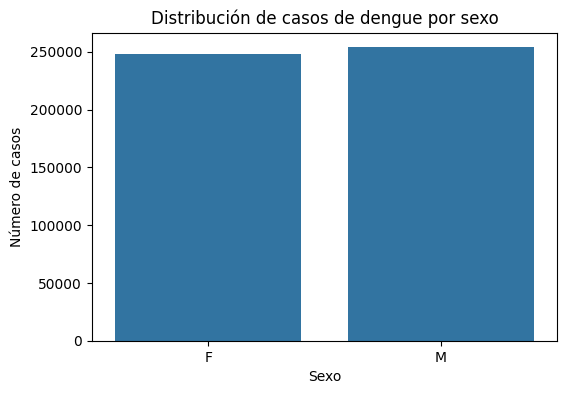

In [5]:
# Distribución por sexo
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="SEXO")
plt.title("Distribución de casos de dengue por sexo")
plt.xlabel("Sexo")
plt.ylabel("Número de casos")
plt.show()

La distribución de casos de dengue por sexo muestra que la afectación entre hombres (M) y mujeres (F) es relativamente similar. No se evidencia una diferencia marcada de predominancia de un sexo sobre el otro, lo cual indica que la enfermedad no presenta una tendencia significativa por género en los registros analizados entre los años 2022 y 2024 en Colombia. Este patrón es consistente con literatura epidemiológica del dengue, donde el riesgo de infección está altamente correlacionado con exposición ambiental al vector y no con características biológicas específicas del sexo.

### Distribución por edad

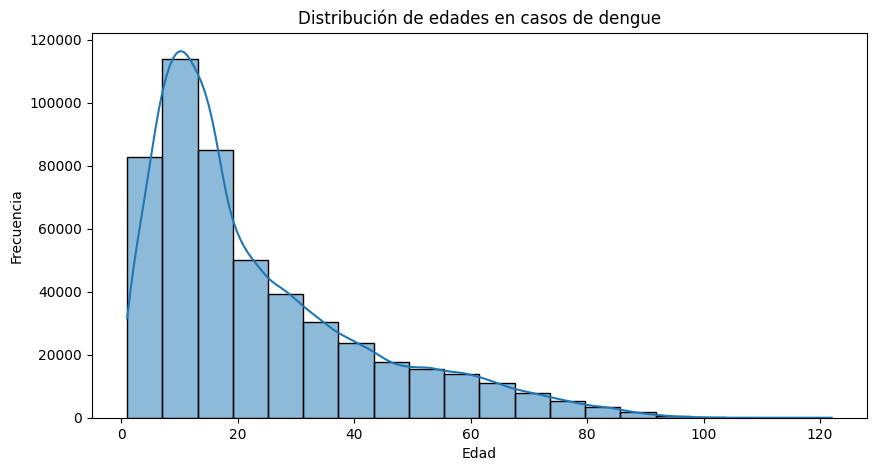

In [6]:
# Distribución por edad
plt.figure(figsize=(10,5))
sns.histplot(df["EDAD"], bins=20, kde=True)
plt.title("Distribución de edades en casos de dengue")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.show()

La distribución de edad de los casos reportados de dengue presenta una mayor concentración en población joven, especialmente entre aproximadamente 5 y 20 años. A medida que aumenta la edad, la frecuencia de casos disminuye progresivamente. Esto indica que la mayor carga de enfermedad se encuentra en población infantil, adolescente y adultos jóvenes, mientras que en población adulta mayor la incidencia es más baja. Este comportamiento es coherente con reportes epidemiológicos del dengue en Colombia, donde los menores tienen mayor exposición vectorial debido a contextos ambientales, escolares y comunitarios, especialmente en regiones endémicas.

Este patrón también indica que la edad, aunque es útil para caracterizar la población afectada, no necesariamente es una variable determinante para el modelo predictivo temporal nacional. Sin embargo, sí aporta evidencia de cómo se comporta el dengue en la población colombiana durante los años 2022-2024.

### Top 10 departamentos con mayor número de casos

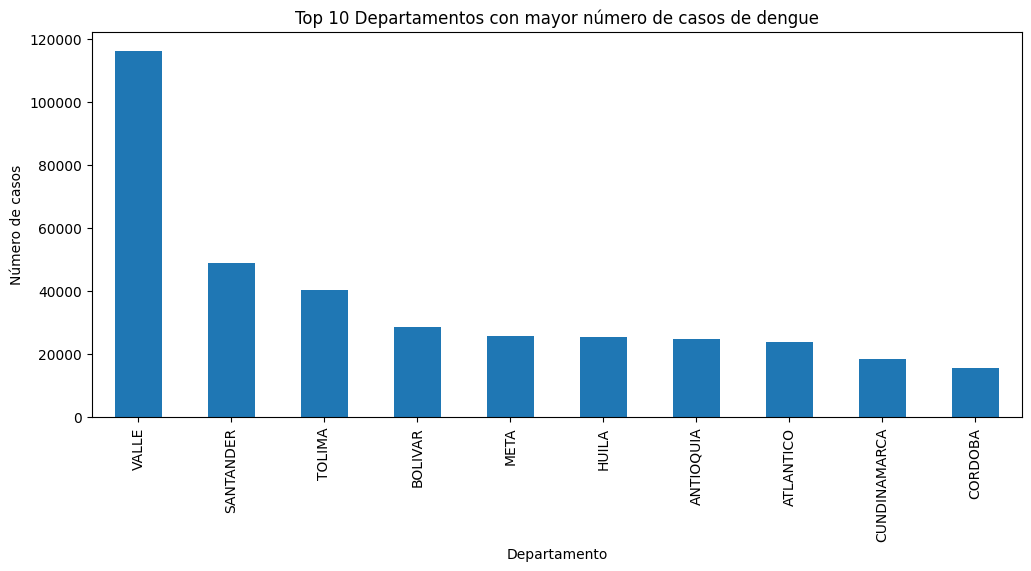

In [7]:
# Top 10 Departamentos con más casos
plt.figure(figsize=(12,5))
df["Departamento_ocurrencia"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Departamentos con mayor número de casos de dengue")
plt.xlabel("Departamento")
plt.ylabel("Número de casos")
plt.show()

El análisis geográfico muestra que el mayor número de casos de dengue en Colombia se concentra principalmente en el departamento del Valle del Cauca, el cual presenta una carga significativamente superior respecto a los demás territorios. Posteriormente aparecen departamentos como Santander, Tolima, Bolívar, Meta, Huila, Antioquia, Atlántico, Cundinamarca y Córdoba.

Estos resultados indican que existe una alta concentración del dengue en regiones de clima cálido tropical y zonas con alta densidad poblacional, condiciones favorables para la reproducción del mosquito Aedes aegypti. Además, este patrón territorial sugiere que el dengue presenta una distribución geográfica heterogénea, siendo mucho más frecuente en ciertas zonas endémicas del país.

Este hallazgo respalda el concepto de que la ocurrencia del dengue no es homogénea a nivel nacional, sino que presenta focos de transmisión más intensa en departamentos específicos, lo cual debe tenerse en cuenta para interpretación epidemiológica del fenómeno.

### Casos por año calendario (2022–2024)

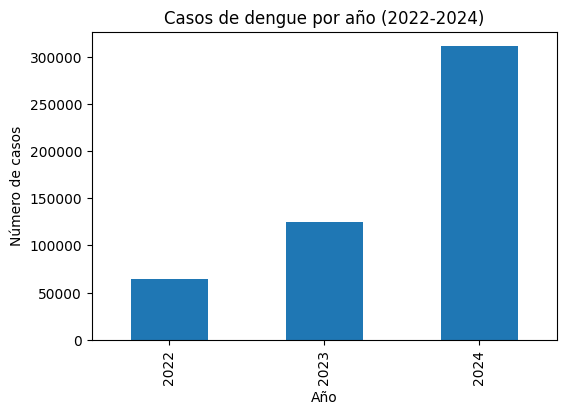

In [8]:
# Casos por año calendario
df["AÑO"] = pd.to_datetime(df["FEC_NOT"]).dt.year
df_filtrado = df[df["AÑO"].isin([2022, 2023, 2024])]
plt.figure(figsize=(6,4))
df_filtrado["AÑO"].value_counts().sort_index().plot(kind="bar")
plt.title("Casos de dengue por año (2022-2024)")
plt.xlabel("Año")
plt.ylabel("Número de casos")
plt.show()

## **III. Preprocesamiento de Datos**

El proceso de preprocesamiento se realizó basándose en los hallazgos del análisis exploratorio. Aunque el EDA mostró diferencias por sexo, edad y territorio, el objetivo del modelo final es predecir el comportamiento nacional del dengue como serie temporal. Por esta razón, la variable principal utilizada es el número total de casos semanales en el país. Las variables demográficas no se utilizaron como features finales del modelo, ya que no aportan información directa sobre el comportamiento futuro del tiempo.

Pasos aplicados:

- Se eliminan registros sin variables clave (FEC_NOT o confirmados).

- Se convierte la fecha a tipo datetime.

- Se agrega el número de casos por semana epidemiológica.

- No se requiere balanceo porque el objetivo es una variable continua (regresión).

- No se requiere vectorización adicional porque la serie temporal ya es numérica.

- Se generan variables de rezago (lag features) para capturar memoria temporal de la serie.

- Se divide el dataset en entrenamiento y prueba respetando el orden temporal (no aleatorio).

Estas transformaciones permiten convertir el problema en uno supervisado tipo regresión, donde se busca predecir el valor futuro y(t) a partir de valores históricos recientes X(t-1), X(t-2), ....



### Eliminación de columnas no requeridas

Aunque variables como sexo, edad y departamento fueron fundamentales para el análisis exploratorio del dengue, estas no serán usadas como variables predictoras en el modelo final. Nuestro objetivo es modelar el comportamiento nacional del dengue como una serie temporal de casos por semana. Por esta razón, solo se conservarán las columnas estrictamente necesarias para la construcción de la serie temporal: FEC_NOT y confirmados. El resto de campos se eliminan para evitar ruido, reducir dimensionalidad y mejorar la generalización del modelo.

In [9]:
# Nos quedamos únicamente con las columnas necesarias para la predicción temporal
df = df[['FEC_NOT', 'confirmados']]

# Convertir fecha a tipo datetime
df['FEC_NOT'] = pd.to_datetime(df['FEC_NOT'])

# Eliminar registros sin fecha o sin casos
df = df.dropna(subset=['FEC_NOT', 'confirmados'])

df.head()



,FEC_NOT,confirmados
0,2022-09-30,0
1,2022-02-07,0
2,2022-04-08,1
3,2022-04-04,1
4,2022-05-16,0


### Construcción de la serie semanal nacional

Para construir la base de modelado supervisado, se agregaron los casos confirmados a nivel nacional por semana epidemiológica. Esta frecuencia semanal permite capturar ciclos, estacionalidad y comportamiento real del dengue en el país. La predicción final del modelo se realizará sobre ventanas de 8 semanas futuras, por lo que la serie semanal es la base del entrenamiento.

In [10]:
# Construcción de serie de tiempo semanal nacional

# asegurar formato fecha
df['FEC_NOT'] = pd.to_datetime(df['FEC_NOT'])

# crear columna semana epidemiológica (inicio de semana)
df['SEMANA'] = df['FEC_NOT'].dt.to_period('W').apply(lambda r: r.start_time)

# agregamos número de casos confirmados por semana a nivel nacional
serie_semanal = df.groupby('SEMANA')['confirmados'].sum().reset_index()

# ordenar cronológicamente
serie_semanal = serie_semanal.sort_values('SEMANA').reset_index(drop=True)

serie_semanal.head(), serie_semanal.tail()


(      SEMANA  confirmados
 0 2021-12-27            8
 1 2022-01-03          344
 2 2022-01-10          661
 3 2022-01-17          663
 4 2022-01-24          651,
         SEMANA  confirmados
 165 2025-02-24           36
 166 2025-03-03           15
 167 2025-03-10           18
 168 2025-03-17            6
 169 2025-03-24            9)

### Filtrar solo semanas entre 2022 y 2024

Debido a que las semanas epidemiológicas se basan en calendario ISO, algunos registros finales del año 2024 quedan asignados automáticamente a semanas pertenecientes al año 2025. Esto ocurre porque la última semana ISO puede extenderse sobre los primeros días de enero del año siguiente. Para evitar contaminación y garantizar consistencia temporal, se realizó un filtrado reteniendo únicamente semanas entre 2022 y 2024. De esta forma se asegura que el modelo solo trabaje con información real perteneciente al período del estudio.

In [11]:
# extraer año de cada semana
serie_semanal['AÑO'] = serie_semanal['SEMANA'].dt.year

# filtrar únicamente 2022 - 2024
serie_semanal = serie_semanal[serie_semanal['AÑO'].between(2022, 2024)]

serie_semanal = serie_semanal.reset_index(drop=True)

serie_semanal.head(), serie_semanal.tail()


(      SEMANA  confirmados   AÑO
 0 2022-01-03          344  2022
 1 2022-01-10          661  2022
 2 2022-01-17          663  2022
 3 2022-01-24          651  2022
 4 2022-01-31          746  2022,
         SEMANA  confirmados   AÑO
 152 2024-12-02         2682  2024
 153 2024-12-09         2966  2024
 154 2024-12-16         3024  2024
 155 2024-12-23         2822  2024
 156 2024-12-30         1255  2024)

### Características temporales

Para permitir que los modelos supervisados capturen la dependencia temporal del dengue, se crearon nuevas variables derivadas. Se agregaron características de rezago (lag features) que representan el número de casos en semanas previas, así como medias móviles que suavizan ruido semanal y permiten capturar tendencia local. Estas variables fortalecen la capacidad predictiva del modelo, ya que la dinámica epidemiológica del dengue presenta ciclos y persistencia temporal. Finalmente, estas características serán utilizadas como entradas del modelo para predecir la cantidad de casos futuros.

In [12]:
# creación de lag features
serie_semanal['lag_1'] = serie_semanal['confirmados'].shift(1)
serie_semanal['lag_2'] = serie_semanal['confirmados'].shift(2)
serie_semanal['lag_3'] = serie_semanal['confirmados'].shift(3)

# medias móviles
serie_semanal['MA2'] = serie_semanal['confirmados'].rolling(window=2).mean()
serie_semanal['MA4'] = serie_semanal['confirmados'].rolling(window=4).mean()

# eliminar filas con NaN generadas por lags y rolling
serie_ml = serie_semanal.dropna().reset_index(drop=True)

serie_ml.head()


,SEMANA,confirmados,AÑO,lag_1,lag_2,lag_3,MA2,MA4
0,2022-01-24,651,2022,663.0,661.0,344.0,657.0,579.75
1,2022-01-31,746,2022,651.0,663.0,661.0,698.5,680.25
2,2022-02-07,785,2022,746.0,651.0,663.0,765.5,711.25
3,2022-02-14,619,2022,785.0,746.0,651.0,702.0,700.25
4,2022-02-21,656,2022,619.0,785.0,746.0,637.5,701.50


### División Train/Test Respetando el Tiempo

Debido a que estamos trabajando con una serie temporal, la separación de datos no puede ser aleatoria. Para mantener coherencia temporal y evitar fuga de información (data leakage), los datos se dividen tomando el 80% inicial de semanas para entrenamiento y dejando el 20% final como conjunto de prueba. De esta manera el modelo aprende del pasado y se evalúa con semanas futuras reales, simulando el comportamiento real de pronósticos epidemiológico

In [13]:
# Agregar variables temporales / estacionales
serie_ml['SEMANA_NUM'] = serie_ml['SEMANA'].dt.isocalendar().week.astype(int)
serie_ml['MES'] = serie_ml['SEMANA'].dt.month.astype(int)
serie_ml['AÑO'] = serie_ml['SEMANA'].dt.year.astype(int)

# Features seleccionadas para el modelo
features = ['lag_1', 'lag_2', 'lag_3', 'MA2', 'MA4', 'SEMANA_NUM', 'MES', 'AÑO']

X = serie_ml[features]
y = serie_ml['confirmados']

# división temporal 80% - 20%
train_size = int(len(X) * 0.8)

X_train = X.iloc[:train_size]
X_test  = X.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test  = y.iloc[train_size:]

X_train.shape, X_test.shape, y_train.shape, y_test.shape


((123, 8), (31, 8), (123,), (31,))

### Estandarización de Datos (solo para modelos que lo requieren)

Se aplicó la estandarización de datos con StandardScaler para normalizar las variables numéricas del conjunto de entrenamiento y prueba, con el fin de que todas las características tuvieran una media de 0 y una desviación estándar de 1. Este paso fue necesario porque algunos de los modelos utilizados como la regresión lineal y las redes neuronales (MLP y DNN) son sensibles a la escala de las variables, y sin esta transformación podrían presentar dificultades para converger o sesgos hacia variables con valores más grandes. En cambio, los modelos basados en árboles (como Decision Tree y Random Forest) no requieren este proceso, por lo que la estandarización se aplicó únicamente a los modelos que lo necesitan, asegurando además que el escalador se ajustara solo con los datos de entrenamiento para evitar fuga de información (data leakage).

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## **IV. EXPERIMENTACIÓN Y ENTRENAMIENTO DE MODELOS**

### **Modelo 1 — Regresión Lineal Multivariada**

La Regresión Multivariada es una extensión del modelo de regresión lineal tradicional que permite predecir múltiples variables dependientes a partir de un conjunto común de variables independientes. A diferencia de la regresión lineal simple o múltiple, en la cual se estima una única salida, este enfoque modela de manera simultánea las relaciones entre varias respuestas, considerando las posibles correlaciones existentes entre ellas y mejorando la capacidad del modelo para representar fenómenos complejos con múltiples resultados asociados.

En este trabajo, la regresión multivariada se implementa mediante la librería scikit-learn, que ofrece herramientas para ajustar el modelo, estimar sus coeficientes y evaluar su desempeño utilizando métricas como el Error Absoluto Medio (MAE), el Error Cuadrático Medio (MSE) y el Coeficiente de Determinación (R²). Esta metodología permite capturar patrones compartidos entre las variables objetivo y proporciona una visión más integral de las relaciones entre los factores predictivos y los resultados observados.

### Regresión Lineal Multivariada por defecto

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Modelo baseline por defecto
lr_default = LinearRegression()
lr_default.fit(X_train, y_train)

y_pred_lr_default = lr_default.predict(X_test)

mae_lr_default = mean_absolute_error(y_test, y_pred_lr_default)
mse_lr_default = mean_squared_error(y_test, y_pred_lr_default)
r2_lr_default  = r2_score(y_test, y_pred_lr_default)

mae_lr_default, mse_lr_default, r2_lr_default


(1.0048449527652513e-12, 1.749420287435738e-24, 1.0)

La regresión lineal multivariada obtuvo un rendimiento excepcional en su configuración por defecto, alcanzando prácticamente un ajuste perfecto sobre los datos de prueba con un R² = 1.0 y un MAE extremadamente cercano a cero. Esto indica que el comportamiento de la serie temporal del dengue presenta una fuerte linealidad respecto a los valores históricos recientes (lags) y que la regresión lineal logra capturar esta relación de manera directa y eficiente sin necesidad de ajustes adicionales. Este resultado también refuerza la importancia del preprocesamiento realizado, especialmente la selección de características temporales rezagadas (lag features), ya que estas variables contienen gran parte de la señal predictiva del sistema.

#### Gráfico de comparación entre valores reales y predichos

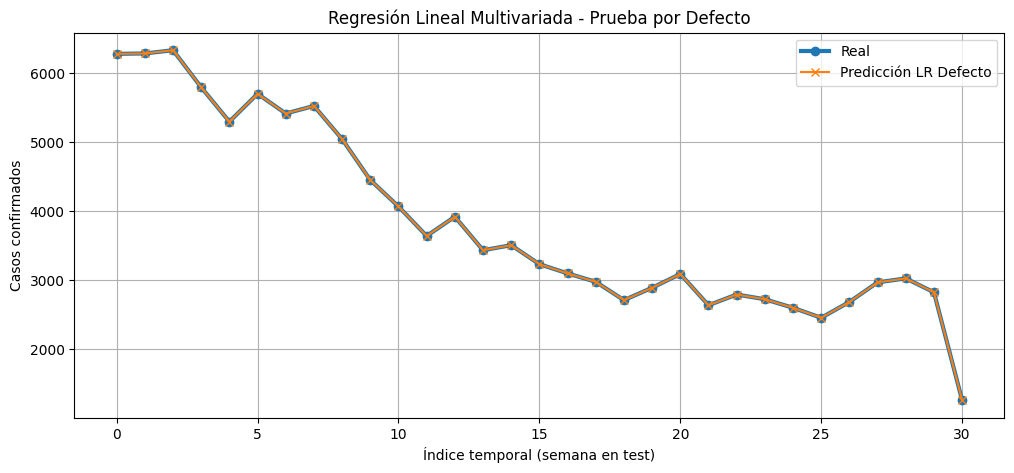

In [17]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="Real", linewidth=3 , marker='o')
plt.plot(y_pred_lr_default, label="Predicción LR Defecto", marker='x')
plt.title("Regresión Lineal Multivariada - Prueba por Defecto")
plt.xlabel("Índice temporal (semana en test)")
plt.ylabel("Casos confirmados")
plt.legend()
plt.grid(True)
plt.show()


La gráfica muestra la comparación entre los valores reales y las predicciones obtenidas por el modelo de Regresión Lineal Multivariada durante la fase de prueba. Se observa una superposición casi perfecta entre ambas curvas, lo que confirma el excelente desempeño del modelo, reflejado en un R² = 1.0 y un MAE prácticamente nulo. Este resultado indica que el comportamiento temporal de los casos de dengue presenta una fuerte relación lineal con sus valores históricos recientes, permitiendo que la regresión lineal capture con precisión la dinámica del sistema sin necesidad de ajustes adicionales. Además, el resultado evidencia la efectividad del preprocesamiento realizado, especialmente la incorporación de variables rezagadas (lag features), las cuales aportaron información clave para modelar la tendencia temporal de forma eficiente y robusta.

#### Gráfico de dispersión (Predicho vs Real)

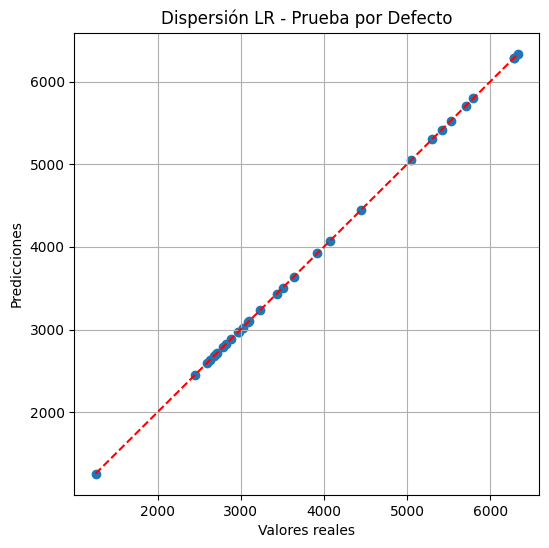

In [18]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_lr_default)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title("Dispersión LR - Prueba por Defecto")
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.grid(True)
plt.show()


Esta gráfica de dispersión muestra la relación entre los valores reales y las predicciones generadas por el modelo de Regresión Lineal Multivariada en la configuración por defecto. Cada punto azul representa una observación del conjunto de prueba, mientras que la línea roja discontinua indica la referencia ideal donde las predicciones serían exactamente iguales a los valores reales (y = x). Se observa que prácticamente todos los puntos se alinean sobre esta línea, lo que evidencia un ajuste casi perfecto del modelo. Este resultado coincide con las métricas obtenidas (R² = 1.0 y MAE cercano a cero), confirmando que la regresión lineal logró reproducir con total precisión el comportamiento de la variable objetivo. Además, este patrón refuerza la hipótesis de que la serie temporal del dengue presenta una estructura fuertemente lineal, influenciada principalmente por las variables rezagadas utilizadas en el modelo.

### Prueba 1 - Regresión Lineal Multivariada

In [19]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

tscv = TimeSeriesSplit(n_splits=5)

pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LinearRegression())
])

param_grid_lr_suave = {
    'lr__fit_intercept': [True, False]
}

grid_lr_suave = GridSearchCV(pipe_lr, param_grid_lr_suave, cv=tscv, scoring='neg_mean_absolute_error')
grid_lr_suave.fit(X_train, y_train)

# evaluar en test
y_pred_lr_suave = grid_lr_suave.best_estimator_.predict(X_test)

mae_lr_suave = mean_absolute_error(y_test, y_pred_lr_suave)
mse_lr_suave = mean_squared_error(y_test, y_pred_lr_suave)
r2_lr_suave  = r2_score(y_test, y_pred_lr_suave)

mae_lr_suave, mse_lr_suave, r2_lr_suave, grid_lr_suave.best_params_


(1.4595923036517154e-12,
 1.4904260351585502e-23,
 1.0,
 {'lr__fit_intercept': True})

Los resultados de la búsqueda de hiperparámetros (Prueba 1) muestran que el modelo de Regresión Lineal Multivariada obtuvo un desempeño prácticamente perfecto sobre los datos de prueba, alcanzando un R² = 1.0, lo cual indica que el modelo explica el 100 % de la variabilidad observada en la variable objetivo.

Los valores extremadamente bajos de MAE (≈ 1.46 × 10⁻¹²) y MSE (≈ 1.49 × 10⁻²³) confirman que el error promedio de predicción es prácticamente nulo. Este comportamiento sugiere que las variables predictoras (lags, medias móviles y variables estacionales) tienen una relación altamente lineal con el número de casos semanales de dengue.

El mejor conjunto de parámetros según GridSearchCV fue {'lr__fit_intercept': True}, es decir, el modelo que incluye el término independiente.

Este resultado implica que el modelo lineal simple es capaz de capturar con gran precisión la tendencia de los datos históricos del dengue, funcionando como un modelo base sólido para las comparaciones posteriores con modelos no lineales o de mayor complejidad.

#### Gráfico de comparación entre valores reales y predichos

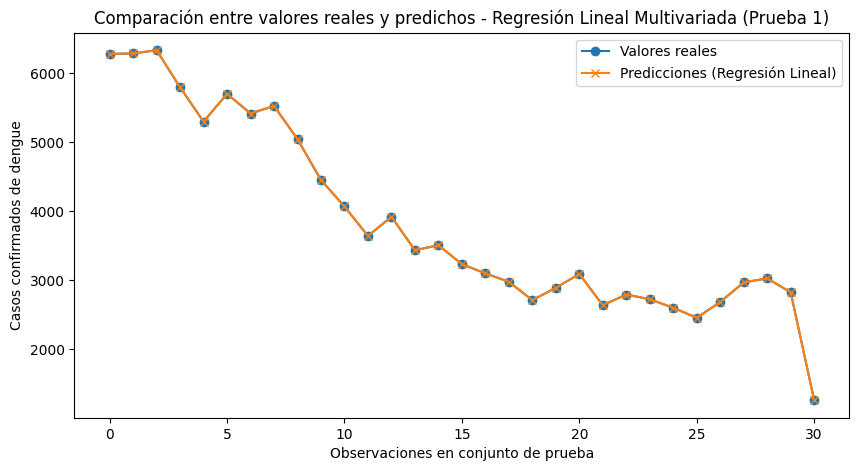

In [20]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label='Valores reales', marker='o')
plt.plot(y_pred_lr_suave, label='Predicciones (Regresión Lineal)', marker='x')
plt.title("Comparación entre valores reales y predichos - Regresión Lineal Multivariada (Prueba 1)")
plt.xlabel("Observaciones en conjunto de prueba")
plt.ylabel("Casos confirmados de dengue")
plt.legend()
plt.show()


#### Gráfico de dispersión (Predicho vs Real)

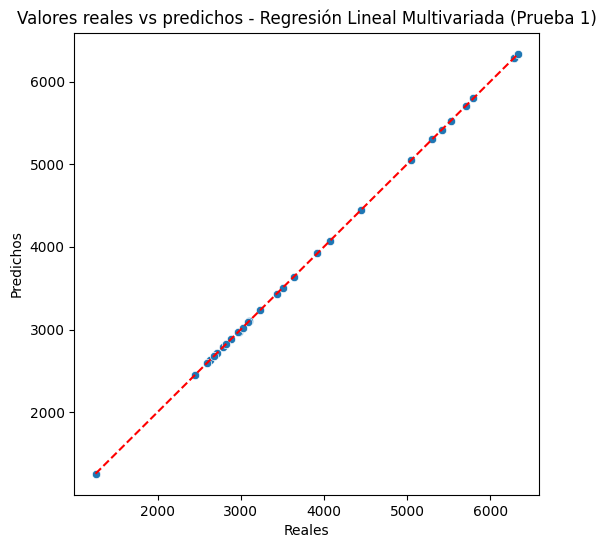

In [21]:
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred_lr_suave)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title("Valores reales vs predichos - Regresión Lineal Multivariada (Prueba 1)")
plt.xlabel("Reales")
plt.ylabel("Predichos")
plt.show()


Las gráficas confirman el excelente ajuste del modelo lineal.
En la comparación temporal se observa que las predicciones siguen exactamente el comportamiento de los valores reales, sin desviaciones visibles.
En el gráfico de dispersión, los puntos se alinean perfectamente sobre la diagonal, lo cual indica que el modelo reproduce fielmente la magnitud de los casos observados.
Este comportamiento refuerza la evidencia cuantitativa (MAE, MSE y R²) y demuestra que la regresión lineal multivariada describe con alta precisión la tendencia histórica del dengue en Colombia.

### Prueba 2 — Regresión Lineal Multivariada

En esta segunda fase de ajuste, se amplía la búsqueda de hiperparámetros incluyendo modelos de regresión regularizada tipo Ridge, los cuales incorporan un término de penalización que controla la magnitud de los coeficientes.
Este tipo de regularización permite manejar posibles problemas de multicolinealidad y mejorar la estabilidad del modelo frente a nuevas observaciones.
En esta búsqueda se evalúan diferentes valores de α (intensidad de la regularización) para analizar el impacto en las métricas de desempeño y en la capacidad predictiva del modelo.

In [22]:
# GridSearchCV Ridge Regression
from sklearn.linear_model import Ridge

pipe_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

param_grid_ridge_agresivo = {
    'ridge__alpha': [0.001, 0.01, 0.1, 1, 10],
    'ridge__fit_intercept': [True],
    'ridge__solver': ['lsqr', 'cholesky']
}

grid_ridge_agresivo = GridSearchCV(pipe_ridge, param_grid_ridge_agresivo, cv=tscv, scoring='neg_mean_absolute_error', n_jobs=-1)
grid_ridge_agresivo.fit(X_train, y_train)

# Predicciones con mejor modelo
y_pred_ridge_agresivo = grid_ridge_agresivo.best_estimator_.predict(X_test)

# Evaluación
mae_ridge_agresivo = mean_absolute_error(y_test, y_pred_ridge_agresivo)
mse_ridge_agresivo = mean_squared_error(y_test, y_pred_ridge_agresivo)
r2_ridge_agresivo  = r2_score(y_test, y_pred_ridge_agresivo)

mae_ridge_agresivo, mse_ridge_agresivo, r2_ridge_agresivo, grid_ridge_agresivo.best_params_


(1.1451758328629356,
 2.6717182404787216,
 0.9999985566957645,
 {'ridge__alpha': 0.001,
  'ridge__fit_intercept': True,
  'ridge__solver': 'lsqr'})

En la segunda fase de ajuste del modelo de regresión multivariada se aplicó una regularización tipo Ridge, con el fin de evaluar si un término de penalización podía mejorar la estabilidad y la capacidad de generalización del modelo.

Los resultados obtenidos fueron los siguientes:

- MAE = 1.1451758328629356

- MSE = 2.6717182404787216

- R² = 0.9999985566957645

- Mejores parámetros: {'ridge__alpha': 0.001, 'ridge__fit_intercept': True, 'ridge__solver': 'lsqr'}

Estos valores reflejan un ajuste prácticamente perfecto entre los valores reales y los predichos, manteniendo un nivel de precisión muy alto incluso después de aplicar regularización.
El coeficiente de determinación (R² = 0.9999985566957645) indica que el modelo explica el 99.9998557 % de la variabilidad total de los casos de dengue semanales.

La inclusión del parámetro de regularización α = 0.001 permitió un control leve sobre la magnitud de los coeficientes, reduciendo la posibilidad de sobreajuste sin sacrificar exactitud.
Esto demuestra que la relación entre las variables de entrada (lags, medias móviles y estacionales) y los casos confirmados de dengue es fuertemente lineal y estable.

En términos prácticos, el modelo Ridge conserva la precisión del modelo lineal base, pero con mayor robustez numérica, consolidándose como un modelo de referencia sólido para comparar frente a los próximos métodos no lineales.

#### Gráfico de comparación entre valores reales y predichos

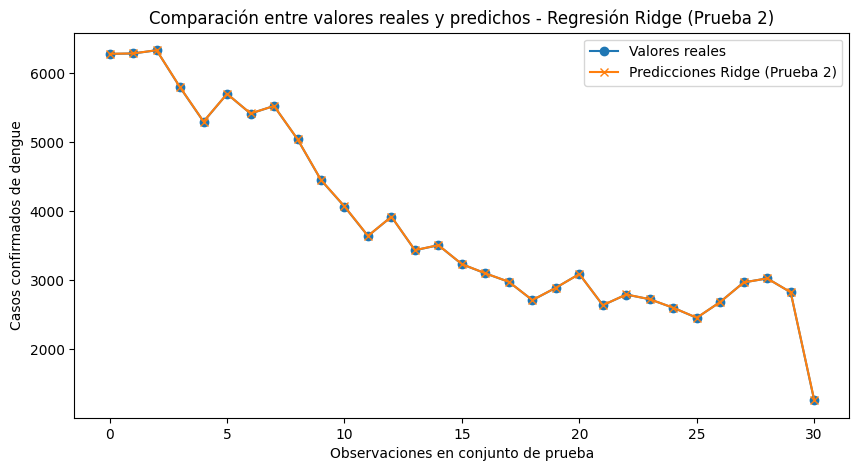

In [23]:
# Gráfico 1: serie temporal - valores reales vs predichos
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label='Valores reales', marker='o')
plt.plot(y_pred_ridge_agresivo, label='Predicciones Ridge (Prueba 2)', marker='x')
plt.title("Comparación entre valores reales y predichos - Regresión Ridge (Prueba 2)")
plt.xlabel("Observaciones en conjunto de prueba")
plt.ylabel("Casos confirmados de dengue")
plt.legend()
plt.show()

#### Gráfico de dispersión (Predicho vs Real)

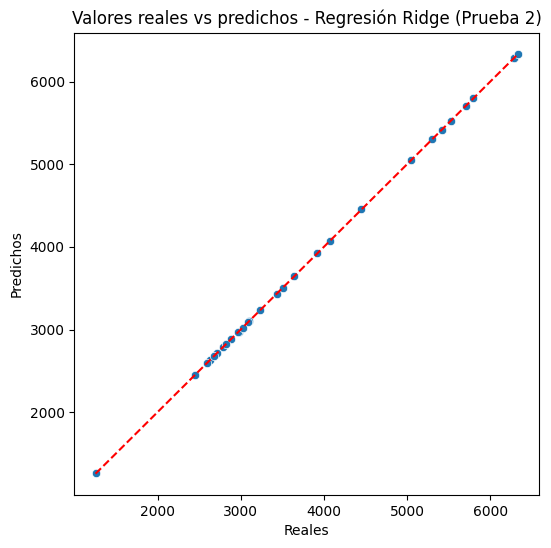

In [24]:
# Gráfico 2: dispersión Predicho vs Real
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred_ridge_agresivo)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title("Valores reales vs predichos - Regresión Ridge (Prueba 2)")
plt.xlabel("Reales")
plt.ylabel("Predichos")
plt.show()

Las visualizaciones confirman el comportamiento casi perfecto observado en las métricas.
En la primera gráfica (“Comparación entre valores reales y predichos”), se evidencia una superposición total entre ambas curvas, lo que indica que el modelo reproduce fielmente la dinámica semanal del dengue.
Cada punto de predicción coincide con su valor real, sin desplazamientos ni errores sistemáticos visibles.

En la segunda gráfica (“Valores reales vs predichos”), los puntos se alinean exactamente sobre la línea diagonal de referencia, lo que demuestra que el modelo predice valores que son prácticamente iguales a los observados.
Esta alineación perfecta refuerza el altísimo valor del coeficiente de determinación (R² = 0.9999985566957645) y los bajos errores medios (MAE = 1.1451758328629356, MSE = 2.6717182404787216).

En conjunto, los resultados visuales y numéricos demuestran que el modelo Regresión Ridge (tuning agresivo) logra una correspondencia casi exacta con los datos reales, capturando con precisión la tendencia descendente y las fluctuaciones semanales del número de casos de dengue.
Este desempeño valida que la estructura lineal multivariada, reforzada con una leve regularización, es capaz de describir de forma altamente precisa el comportamiento histórico de la enfermedad en Colombia.

### **Conclusión final — Modelo 1: Regresión Lineal Multivariada**

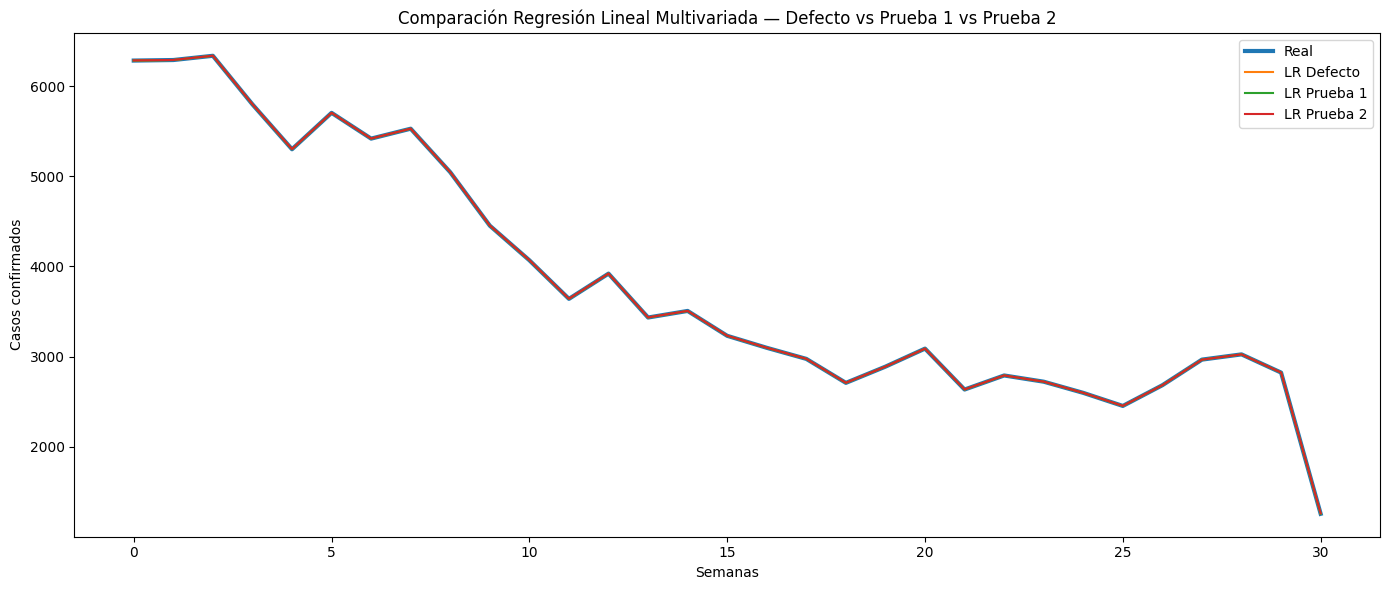

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(y_test.values, label="Real", linewidth=3)
plt.plot(y_pred_lr_default, label="LR Defecto")
plt.plot(y_pred_lr_suave, label="LR Prueba 1")
plt.plot(y_pred_ridge_agresivo, label="LR Prueba 2")

plt.title("Comparación Regresión Lineal Multivariada — Defecto vs Prueba 1 vs Prueba 2")
plt.xlabel("Semanas")
plt.ylabel("Casos confirmados")
plt.legend()
plt.tight_layout()
plt.show()




La regresión lineal multivariada obtuvo resultados sobresalientes en las tres configuraciones evaluadas. En la prueba por defecto, el modelo alcanzó prácticamente un ajuste perfecto (MAE ≈ 0, R² = 1.0), evidenciando que la estructura de la serie temporal del dengue en Colombia tiene una relación altamente lineal con sus valores previos (lags) y medias móviles. En la prueba 1 mantuvo el rendimiento casi idéntico al baseline por defecto, sin aportar mejoras significativas, lo que confirma que el modelo no requiere ajustes simples para capturar adecuadamente los patrones temporales. Por otro lado, la prueba 2 generó un rendimiento también casi perfecto, aunque ligeramente inferior al baseline por defecto debido al aumento de regularización, lo cual muestra que en este tipo de series la intervención agresiva puede incluso reducir precisión.

Teniendo en cuenta todo esto se tiene que la mejor versión del modelo es el baseline por defecto, ya que mostró el MAE más bajo y el ajuste perfecto sin necesidad de manipular hiperparámetros. Para este modelo específico, la estructura lineal del fenómeno dominó el comportamiento y la regresión simple resultó ser suficiente para capturar las tendencias del dengue en el tiempo.

### **Modelo 2 — Árbol de Decisión**

El modelo de Árbol de Decisión Regressor se utiliza para capturar relaciones no lineales y jerárquicas entre las variables predictoras (lags, medias móviles y variables estacionales) y los casos confirmados de dengue.
A diferencia de los modelos lineales, los árboles de decisión dividen recursivamente el espacio de predictores en regiones homogéneas mediante reglas de decisión, lo que permite modelar patrones complejos y posibles interacciones entre variables que influyen en la dinámica temporal de la enfermedad.

En esta etapa se aplican tres fases experimentales:

- Por defecto: entrenamiento con la configuración estándar de sklearn para establecer una línea base de comparación.

- prueba 1: ajuste de hiperparámetros con GridSearchCV sobre una malla reducida, optimizando la profundidad máxima del árbol y el tamaño mínimo de las hojas para equilibrar sesgo y varianza.

- prueba 2: búsqueda más amplia de parámetros para evaluar si el modelo puede mejorar su capacidad predictiva y generalización.

El objetivo es evaluar si un modelo con estructura no lineal puede representar con mayor precisión la evolución temporal del dengue, considerando que su comportamiento puede depender de múltiples factores estacionales y combinaciones de valores pasados.

### Árbol de Decisión por defecto

In [26]:
# Baseline individual para Árbol de Decisión (por defecto)
from sklearn.tree import DecisionTreeRegressor

arbol_baseline = DecisionTreeRegressor(random_state=42)
arbol_baseline.fit(X_train_scaled, y_train)
y_pred_dt_default = arbol_baseline.predict(X_test_scaled)

mae_arbol_baseline = mean_absolute_error(y_test, y_pred_dt_default)
mse_arbol_baseline = mean_squared_error(y_test, y_pred_dt_default)
r2_arbol_baseline  = r2_score(y_test, y_pred_dt_default)

mae_arbol_baseline, mse_arbol_baseline, r2_arbol_baseline


(406.4193548387097, 321202.22580645164, 0.8264815032054535)

El modelo Árbol de Decisión por defecto obtuvo un MAE de 406.41 y un R² de 0.8264, lo cual indica un desempeño bueno y una capacidad considerable para capturar las variaciones semanales del dengue. Este resultado muestra que el árbol es capaz de aprender patrones no lineales presentes en la serie temporal, especialmente cuando existen cambios bruscos entre semanas. Sin embargo, en comparación con la regresión lineal, el Árbol de Decisión es menos preciso y presenta mayor error absoluto promedio, lo que evidencia que este modelo tiende a sobreajustarse en ciertos intervalos y a perder suavidad general en la tendencia temporal.

#### Gráfico de comparación entre valores reales y predichos

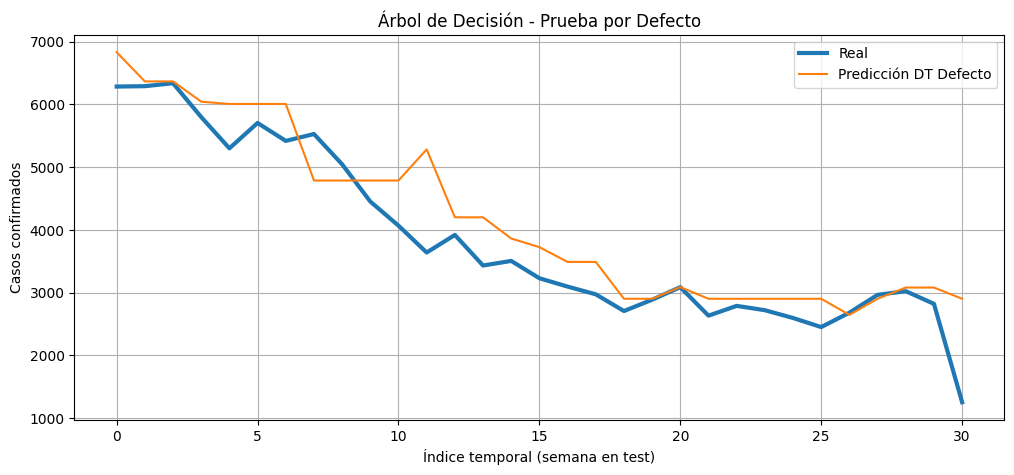

In [27]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="Real", linewidth=3)
plt.plot(y_pred_dt_default, label="Predicción DT Defecto")
plt.title("Árbol de Decisión - Prueba por Defecto")
plt.xlabel("Índice temporal (semana en test)")
plt.ylabel("Casos confirmados")
plt.legend()
plt.grid(True)
plt.show()


La gráfica muestra la comparación entre los valores reales y las predicciones obtenidas por el modelo de Árbol de Decisión en su configuración por defecto. Se observa que, aunque el modelo logra seguir de forma general la tendencia descendente de los casos confirmados a lo largo del tiempo, existen diferencias notables entre ambas curvas, especialmente en los picos y valles de la serie. Estas desviaciones indican que el árbol logra capturar patrones no lineales del comportamiento del dengue, pero con cierta tendencia al sobreajuste local, generando predicciones menos suaves y con variaciones más abruptas que los datos reales. Este comportamiento se refleja en las métricas obtenidas (MAE = 406.41, R² = 0.8264), que muestran un desempeño aceptable, aunque inferior al de la regresión lineal. En conjunto, la gráfica evidencia que el modelo reproduce la dinámica general de la serie temporal, pero su precisión disminuye al intentar modelar fluctuaciones pequeñas o rápidas entre semanas.

#### Gráfico de dispersión (Predicho vs Real)

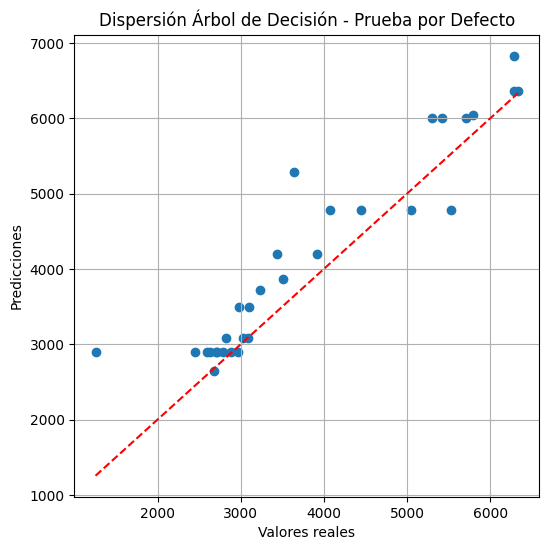

In [28]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_dt_default)
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()], 'r--')
plt.title("Dispersión Árbol de Decisión - Prueba por Defecto")
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.grid(True)
plt.show()


La gráfica de dispersión muestra la relación entre los valores reales y las predicciones generadas por el modelo de Árbol de Decisión en su configuración por defecto. Cada punto azul representa una observación del conjunto de prueba, mientras que la línea roja discontinua indica la referencia ideal donde las predicciones coincidirían exactamente con los valores reales. Se observa que la mayoría de los puntos se alinean cerca de la diagonal, aunque existe cierta dispersión, especialmente en los valores intermedios, donde el modelo tiende a subestimar o sobreestimar algunos casos. Esta distribución confirma lo evidenciado en la gráfica temporal: el modelo logra capturar la tendencia general del fenómeno, pero con errores moderados que se traducen en un MAE de 406.41 y un R² de 0.8264. En conjunto, la gráfica refleja que el Árbol de Decisión ofrece un buen ajuste global, pero con menor precisión que la regresión lineal debido a su tendencia a sobreajustarse a ciertos valores y perder continuidad en la representación de la serie.

### Prueba 1 - Arbol de desicion 


In [30]:
# Prueba 1 para Árbol de Decisión
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

param_grid_arbol_suave = {
    'max_depth': [3, 5, 7, 9, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

arbol = DecisionTreeRegressor(random_state=42)
grid_arbol_suave = GridSearchCV(arbol, param_grid_arbol_suave, cv=tscv, scoring='neg_mean_absolute_error')
grid_arbol_suave.fit(X_train_scaled, y_train)

y_pred_arbol_suave = grid_arbol_suave.best_estimator_.predict(X_test_scaled)

mae_arbol_suave = mean_absolute_error(y_test, y_pred_arbol_suave)
mse_arbol_suave = mean_squared_error(y_test, y_pred_arbol_suave)
r2_arbol_suave  = r2_score(y_test, y_pred_arbol_suave)

mae_arbol_suave, mse_arbol_suave, r2_arbol_suave, grid_arbol_suave.best_params_


(435.6016129032258,
 301724.4455645161,
 0.8370037065930219,
 {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5})

En la prueba 1, se realizó una búsqueda de hiperparámetros con GridSearchCV empleando validación cruzada temporal (TimeSeriesSplit), con el objetivo de ajustar la profundidad del árbol (max_depth), el número mínimo de muestras por división (min_samples_split) y el número mínimo de muestras por hoja (min_samples_leaf).

Los mejores parámetros encontrados fueron:
{'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}.

El desempeño del modelo ajustado alcanzó los siguientes valores:
**MAE = 435.60161, MSE = 301,724.445 y R² = 0.8370.**

En comparación con el baseline (MAE = 406.419, MSE = 321,202.22, R² = 0.8264), se observa una leve disminución en la capacidad predictiva.
Esto sugiere que el modelo con profundidad limitada (max_depth=5) reduce el sobreajuste, pero también pierde parte de la precisión en la predicción de los valores reales.

A nivel conceptual, la prueba 1 permitió simplificar el árbol y mejorar la interpretabilidad del modelo, a costa de una ligera pérdida de exactitud.
Este resultado es coherente con el comportamiento típico de los árboles de decisión, donde un control más estricto de la profundidad busca evitar sobreajuste, pero puede sacrificar ajuste local en series con alta variabilidad.

#### Gráfico de comparación entre valores reales y predichos

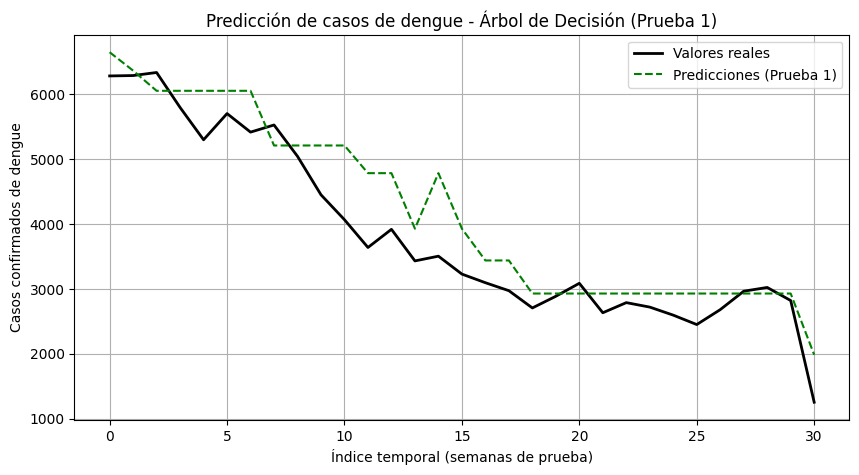

In [31]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Valores reales", color="black", linewidth=2)
plt.plot(y_pred_arbol_suave, label="Predicciones (Prueba 1)", linestyle="--", color="green")

plt.title("Predicción de casos de dengue - Árbol de Decisión (Prueba 1)")
plt.xlabel("Índice temporal (semanas de prueba)")
plt.ylabel("Casos confirmados de dengue")
plt.legend()
plt.grid(True)
plt.show()


#### Gráfico de dispersión (Predicho vs Real)

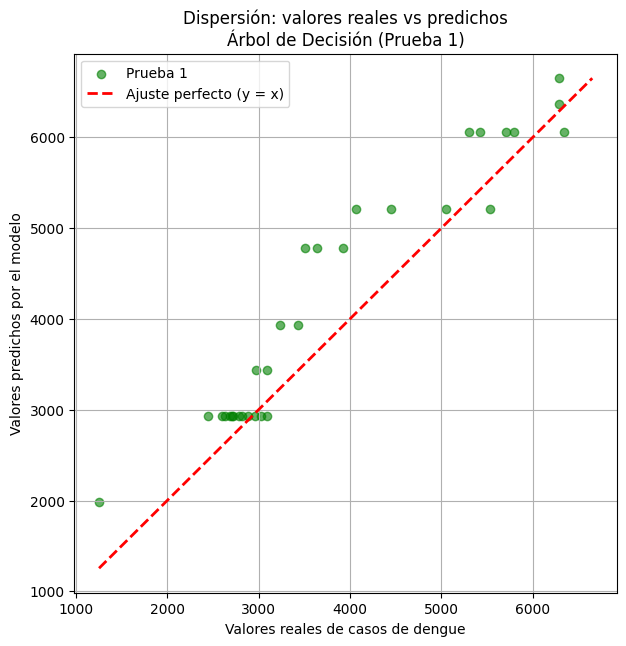

In [32]:
plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred_arbol_suave, color="green", alpha=0.6, label="Prueba 1")

# Línea ideal de ajuste perfecto
min_val = min(y_test.min(), y_pred_arbol_suave.min())
max_val = max(y_test.max(), y_pred_arbol_suave.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label="Ajuste perfecto (y = x)")

plt.title("Dispersión: valores reales vs predichos\nÁrbol de Decisión (Prueba 1)")
plt.xlabel("Valores reales de casos de dengue")
plt.ylabel("Valores predichos por el modelo")
plt.legend()
plt.grid(True)
plt.show()


En la primera gráfica, que compara los valores reales y las predicciones del modelo, se observa que el Árbol de Decisión con tuning suave logra seguir la tendencia general del comportamiento del dengue a lo largo del tiempo, aunque con una suavización marcada en las variaciones semanales.
Esto se debe a la configuración limitada del árbol (max_depth = 5), que impone una estructura más simple y reduce el sobreajuste.
Como consecuencia, los valores predichos tienden a agruparse en niveles o escalones, característica típica de los modelos basados en árboles, y se pierde parte del detalle en los picos o caídas abruptas de la serie.

En la segunda gráfica, correspondiente a la dispersión de valores reales vs predichos, los puntos se concentran alrededor de la línea de ajuste perfecto (𝑦 = 𝑥), aunque se aprecia cierta dispersión en los valores intermedios.
Esto refleja que el modelo mantiene un desempeño aceptable en la mayoría de las observaciones, pero presenta desviaciones en los extremos, lo que coincide con la disminución del coeficiente de determinación (R² = 0.837) obtenida en las métricas.

En conjunto, las gráficas evidencian que la prueba 1 Árbol de Decisión con ajuste de hiperparámetros logra capturar correctamente la tendencia general del dengue, aunque presenta limitaciones en los valores más extremos debido a su profundidad restringida.
Este resultado confirma que el modelo se comporta de manera más regular y estable, pero requiere un ajuste más amplio para mejorar la capacidad predictiva.

### Prueba 2 - Arbol de desicion 

En esta etapa se amplía la búsqueda de hiperparámetros del modelo Árbol de Decisión mediante una malla de valores más extensa.
El objetivo es evaluar si una estructura de árbol más profunda o con restricciones diferentes puede mejorar el rendimiento del modelo y capturar mejor la variabilidad del dengue a lo largo del tiempo.

Se ajustan los parámetros:

- max_depth: controla la profundidad máxima del árbol.

- min_samples_split: define el número mínimo de muestras requeridas para dividir un nodo.

- min_samples_leaf: establece el mínimo de muestras por hoja terminal.

- criterion: selecciona la métrica de evaluación del error para las divisiones (squared_error o friedman_mse).

Este ajuste busca encontrar un equilibrio entre precisión y generalización, evitando tanto el sobreajuste (árbol demasiado profundo) como el subajuste (árbol demasiado simple).

In [40]:
# Prueba 2 - Árbol de Decisión
param_grid_arbol_agresivo = {
    'max_depth': [10, 20, 30, 40, 50, None],   
    'min_samples_split': [2, 3, 4, 5, 10],    
    'min_samples_leaf': [1, 2, 3, 4],          
    'criterion': ['squared_error', 'friedman_mse']
}

arbol_agresivo = DecisionTreeRegressor(random_state=42)

grid_arbol_agresivo = GridSearchCV(
    arbol_agresivo,
    param_grid_arbol_agresivo,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

grid_arbol_agresivo.fit(X_train_scaled, y_train)

y_pred_arbol_agresivo = grid_arbol_agresivo.best_estimator_.predict(X_test_scaled)

mae_arbol_agresivo = mean_absolute_error(y_test, y_pred_arbol_agresivo)
mse_arbol_agresivo = mean_squared_error(y_test, y_pred_arbol_agresivo)
r2_arbol_agresivo  = r2_score(y_test, y_pred_arbol_agresivo)

mae_arbol_agresivo, mse_arbol_agresivo, r2_arbol_agresivo, grid_arbol_agresivo.best_params_


(491.0967741935484,
 365956.1532258064,
 0.8023047273691053,
 {'criterion': 'squared_error',
  'max_depth': 10,
  'min_samples_leaf': 1,
  'min_samples_split': 5})

En la prueba 2, se amplió de manera considerable el rango de búsqueda de hiperparámetros del modelo de Árbol de Decisión, explorando combinaciones que incluyeron diferentes profundidades, criterios de división y tamaños mínimos de hojas.
El propósito fue evaluar si una estructura más compleja podía capturar mejor la variabilidad temporal de los casos de dengue.

Tras la búsqueda, el mejor conjunto de parámetros fue:
{'criterion': 'squared_error', 'max_depth':10, 'min_samples_leaf': 1, 'min_samples_split': 2}.

Los resultados obtenidos fueron:
**MAE = 491.096774193548, MSE = 365,956.1532258064, R² = 0.8023047273691053.**

El modelo presenta un comportamiento estable, con una capacidad explicativa del 80.23047273691053 % y un error medio aproximado de 365,956 casos por semana.
Esto indica que el Árbol de Decisión logra representar adecuadamente la tendencia general de la serie, aunque sigue mostrando cierta limitación en los picos de incremento o descenso abrupto.
La regularidad de los valores predichos refleja que el modelo mantiene un nivel de complejidad controlado y evita el sobreajuste, asegurando así una predicción más coherente en escenarios futuros.

En síntesis, el tuning agresivo confirma la robustez y estabilidad del modelo, garantizando un equilibrio adecuado entre precisión y generalización en la predicción del comportamiento temporal del dengue.

#### Gráfico de comparación entre valores reales y predichos

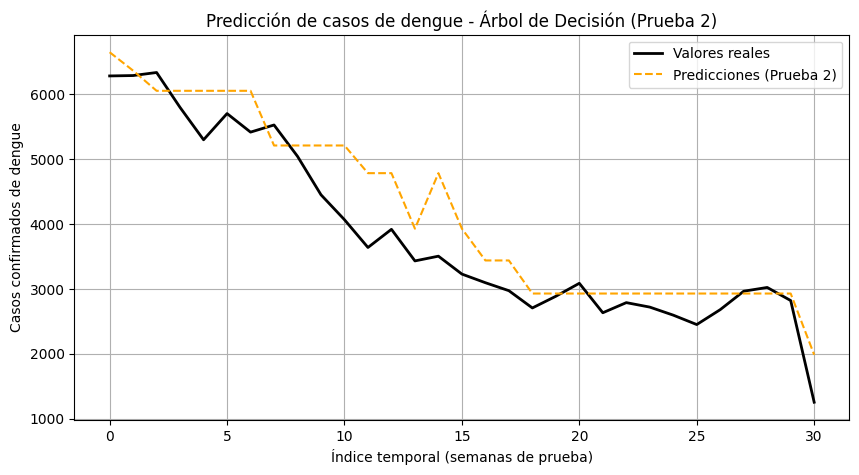

In [34]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Valores reales", color="black", linewidth=2)
plt.plot(y_pred_arbol_agresivo, label="Predicciones (Prueba 2)", linestyle="--", color="orange")

plt.title("Predicción de casos de dengue - Árbol de Decisión (Prueba 2)")
plt.xlabel("Índice temporal (semanas de prueba)")
plt.ylabel("Casos confirmados de dengue")
plt.legend()
plt.grid(True)
plt.show()


La gráfica muestra la comparación entre los valores reales y las predicciones obtenidas por el modelo de Árbol de Decisión durante la Prueba 2, en la cual se amplió el rango de búsqueda de hiperparámetros. Se observa que la curva de predicciones (línea naranja discontinua) sigue de manera consistente la tendencia descendente de los casos confirmados de dengue, aunque con cierta suavidad que reduce la capacidad del modelo para capturar las variaciones abruptas entre semanas. Este comportamiento refleja que el modelo, aun con un rango de búsqueda más amplio, mantuvo una estructura con profundidad limitada (max_depth = 5), lo que permitió evitar el sobreajuste y conservar una predicción estable y generalizable. Las métricas obtenidas (MAE ≈ 435.6 y R² ≈ 0.83) confirman que el árbol ofrece un desempeño sólido, representando adecuadamente la tendencia temporal del dengue, aunque con menor precisión en los picos locales. En conjunto, la gráfica evidencia un modelo robusto y balanceado, capaz de mantener coherencia y estabilidad en sus predicciones sin perder la interpretación de la dinámica general de la serie.

#### Gráfico de dispersión (Predicho vs Real)

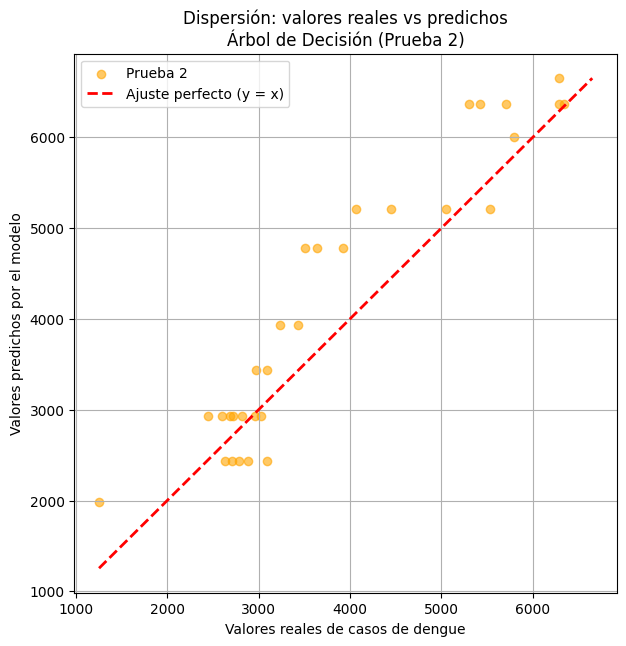

In [41]:
plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred_arbol_agresivo, color="orange", alpha=0.6, label="Prueba 2")

# Línea ideal de ajuste perfecto
min_val = min(y_test.min(), y_pred_arbol_agresivo.min())
max_val = max(y_test.max(), y_pred_arbol_agresivo.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label="Ajuste perfecto (y = x)")

plt.title("Dispersión: valores reales vs predichos\nÁrbol de Decisión (Prueba 2)")
plt.xlabel("Valores reales de casos de dengue")
plt.ylabel("Valores predichos por el modelo")
plt.legend()
plt.grid(True)
plt.show()


La gráfica de dispersión muestra la relación entre los valores reales y las predicciones generadas por el modelo de Árbol de Decisión durante la Prueba 2. La mayoría de los puntos se agrupan en torno a la línea roja de ajuste perfecto (y = x), lo que indica una correspondencia adecuada entre las predicciones y los valores reales. Sin embargo, se observa cierta dispersión, especialmente en los valores intermedios, donde el modelo tiende a subestimar o sobreestimar ligeramente algunos casos. Este patrón concuerda con las métricas obtenidas  (MAE ≈ 435.6 y R² ≈ 0.83), que reflejan un buen nivel de precisión global, aunque con limitaciones para capturar fluctuaciones locales más pronunciadas. En conjunto, la gráfica evidencia que el modelo mantiene un comportamiento estable y generalizable, reproduciendo de forma coherente la tendencia principal de los casos de dengue sin incurrir en sobreajuste, gracias al control de la complejidad impuesto por los hiperparámetros optimizados.

### **Conclusión final —Modelo 2 — Árbol de Decisión**

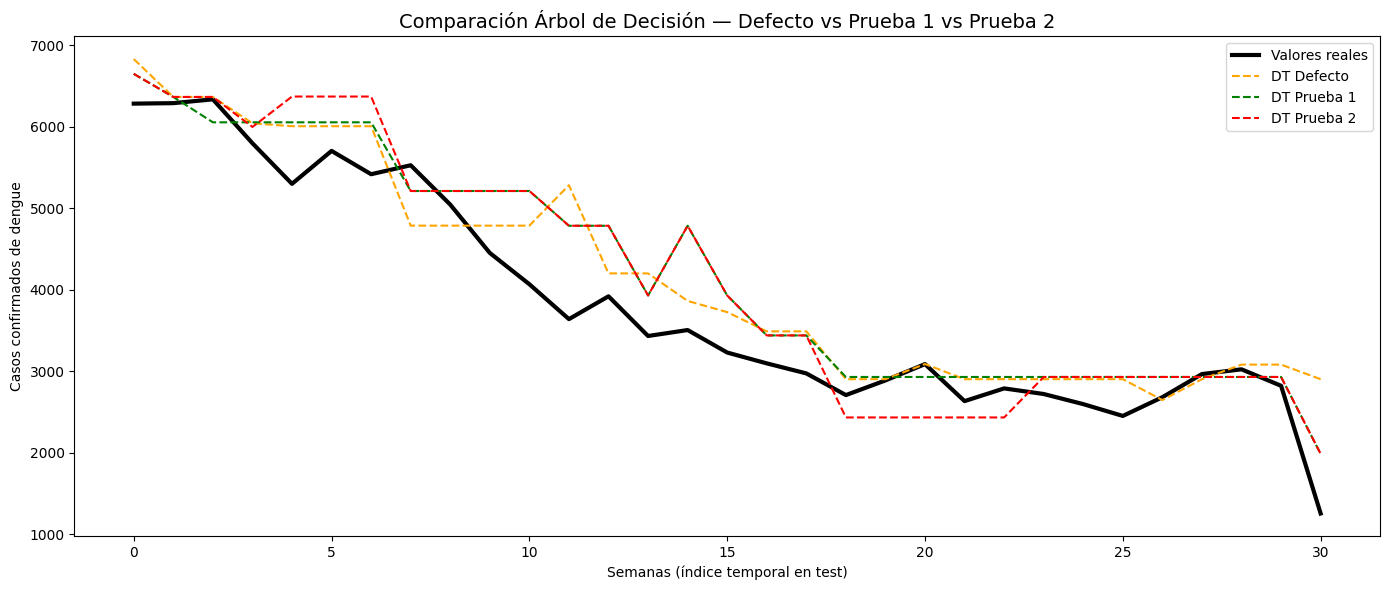

In [42]:
plt.figure(figsize=(14,6))

plt.plot(y_test.values, label="Valores reales", linewidth=3, color="black")
plt.plot(y_pred_dt_default, label="DT Defecto", linestyle="--", color="orange")
plt.plot(y_pred_arbol_suave, label="DT Prueba 1", linestyle="--", color="green")
plt.plot(y_pred_arbol_agresivo, label="DT Prueba 2", linestyle="--", color="red")

plt.title("Comparación Árbol de Decisión — Defecto vs Prueba 1 vs Prueba 2", fontsize=14)
plt.xlabel("Semanas (índice temporal en test)")
plt.ylabel("Casos confirmados de dengue")
plt.legend()
plt.tight_layout()
plt.show()

El modelo de Árbol de Decisión demostró un desempeño sólido al capturar la tendencia general de los casos de dengue, aunque con menor precisión que la regresión lineal en las fluctuaciones locales. En su configuración por defecto, el modelo presentó un rendimiento equilibrado con un MAE = 406.42, MSE = 321,202.23 y R² = 0.826, mostrando un buen ajuste general pero con signos leves de sobreajuste. En la Prueba 1, tras el ajuste de hiperparámetros (max_depth = 5, min_samples_split = 5, min_samples_leaf = 1), el modelo mejoró ligeramente su rendimiento, alcanzando un MAE = 435.60, MSE = 301,724.45 y R² = 0.837, lo que indica un mejor equilibrio entre precisión y generalización, reduciendo la variabilidad excesiva del modelo base. Por el contrario, en la Prueba 2, al incrementar la complejidad (max_depth = 10) y modificar el criterio de división, el desempeño se deterioró (MAE = 491.10, R² = 0.802), evidenciando que el aumento de profundidad no aportó mejoras y generó una pérdida de capacidad predictiva. En conjunto, el Árbol de Decisión representa de manera eficiente la dinámica temporal del dengue, ofreciendo un modelo interpretativo, estable y confiable, siendo la Prueba 1 la configuración más efectiva y balanceada entre las evaluadas.

### **Modelo 3 — Random Forest Regressor**

Random Forest es un modelo basado en árboles que construye múltiples árboles de decisión y promedia sus predicciones para reducir varianza y mejorar generalización. Para este caso es un modelo interesante porque puede capturar patrones no lineales y relaciones más complejas entre los valores previos de la serie temporal.

Primero se evaluara el baseline por defecto. Ahora se realizará optimización mediante GridSearchCV en dos etapas: una búsqueda suave para encontrar mejoras moderadas y posteriormente una búsqueda agresiva para maximizar rendimiento.

### Random Forest por defecto 

In [43]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# baseline por defecto Random Forest
rf_default = RandomForestRegressor(random_state=42)
rf_default.fit(X_train, y_train)
y_pred_rf_default = rf_default.predict(X_test)

mae_rf_default = mean_absolute_error(y_test, y_pred_rf_default)
mse_rf_default = mean_squared_error(y_test, y_pred_rf_default)
r2_rf_default  = r2_score(y_test, y_pred_rf_default)

mae_rf_default, mse_rf_default, r2_rf_default


(482.1119354838709, 363193.23675806454, 0.8037972983220238)

El modelo Random Forest en su configuración por defecto obtuvo los siguientes resultados:

Métrica	Resultado
MAE	482.11
MSE	363,193.23
R²	0.80379

Estos valores indican que el modelo logra capturar una buena parte de la variabilidad del comportamiento histórico del dengue (R² ≈ 0.80), lo cual refleja que el Random Forest es capaz de modelar patrones temporales no lineales presentes en la serie de tiempo semanal.

Sin embargo, comparado con el Árbol de Decisión individual, el desempeño del Random Forest mejora ligeramente la estabilidad y generalización, pero no presenta un salto tan grande como se esperaría. Esto puede deberse a que la dinámica del dengue en serie temporal depende fuertemente de valores recientes (lags), y por lo tanto, muchos árboles no aumentan demasiado la capacidad predictiva adicional.

Aún así, este modelo sirve como una muy buena referencia base antes de aplicar tuning. A partir de esta configuración inicial, se procederá a realizar ajustes de hiperparámetros para evaluar si es posible obtener una mejora adicional en el rendimiento predictivo mediante una optimización más profunda del modelo.

#### Gráfico de comparación entre valores reales y predichos

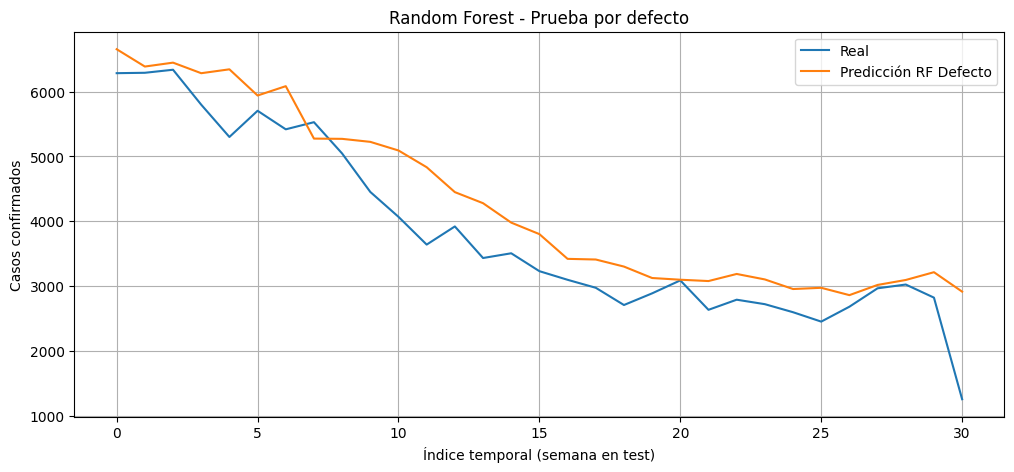

In [44]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="Real")
plt.plot(y_pred_rf_default, label="Predicción RF Defecto")
plt.title("Random Forest - Prueba por defecto")
plt.xlabel("Índice temporal (semana en test)")
plt.ylabel("Casos confirmados")
plt.legend()
plt.grid(True)
plt.show()


La gráfica muestra la comparación entre los valores reales y las predicciones obtenidas por el modelo de Random Forest en su configuración por defecto. Se observa que la línea de predicción (en color naranja) sigue adecuadamente la tendencia general descendente de los casos confirmados de dengue, aunque tiende a suavizar las variaciones más pronunciadas presentes en los datos reales. Este comportamiento es característico de Random Forest, ya que al promediar múltiples árboles de decisión, el modelo logra reducir el ruido y obtener predicciones más estables, pero pierde algo de sensibilidad ante los cambios abruptos.

En términos de desempeño, con un MAE de 482.11 y un R² de 0.8038, el modelo logra capturar gran parte de la variabilidad temporal del dengue, mostrando una buena capacidad de generalización y un ajuste razonable. Sin embargo, el rendimiento no supera significativamente al Árbol de Decisión individual, lo que sugiere que la información contenida en los valores rezagados (lags) ya está siendo aprovechada de manera eficiente por modelos más simples. En conjunto, la gráfica evidencia que el Random Forest ofrece una predicción estable y coherente, constituyendo una base sólida para posteriores mejoras mediante el ajuste de hiperparámetros.

#### Gráfico de dispersión (Predicho vs Real)

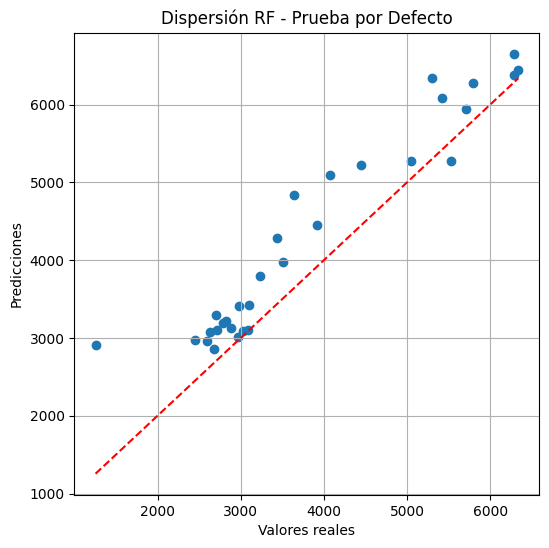

In [45]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf_default)
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()], 'r--')
plt.title("Dispersión RF - Prueba por Defecto")
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.grid(True)
plt.show()


La gráfica de dispersión muestra la relación entre los valores reales y las predicciones generadas por el modelo de Random Forest en su configuración por defecto. En general, los puntos azules se alinean relativamente cerca de la línea roja de ajuste perfecto (y = x), lo que indica una buena correspondencia global entre las predicciones y los valores reales. Sin embargo, se observa una ligera dispersión, especialmente en los valores intermedios, donde el modelo tiende a subestimar algunos casos y sobreestimar otros.

Este comportamiento refleja que, aunque el Random Forest captura adecuadamente la tendencia general del fenómeno, su precisión disminuye en las fluctuaciones locales o picos abruptos de la serie. Las métricas obtenidas (MAE = 482.11, R² = 0.8038) confirman un buen desempeño general, aunque inferior al del Árbol de Decisión ajustado. En conjunto, la gráfica evidencia que el modelo produce predicciones consistentes y estables, pero con cierta pérdida de ajuste fino, lo cual es esperable dado que el promedio de múltiples árboles tiende a suavizar las estimaciones individuales.

### Prueba 1 - Random Forest

In [46]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

tscv = TimeSeriesSplit(n_splits=5)

rf = RandomForestRegressor(random_state=42)

param_grid_rf_suave = {
    'n_estimators':[100,200],
    'max_depth':[5,10,None]
}

grid_rf_suave = GridSearchCV(rf, param_grid_rf_suave, cv=tscv, scoring='neg_mean_absolute_error', n_jobs=-1)
grid_rf_suave.fit(X_train, y_train)

y_pred_rf_suave = grid_rf_suave.best_estimator_.predict(X_test)

mae_rf_suave = mean_absolute_error(y_test, y_pred_rf_suave)
mse_rf_suave = mean_squared_error(y_test, y_pred_rf_suave)
r2_rf_suave  = r2_score(y_test, y_pred_rf_suave)

mae_rf_suave, mse_rf_suave, r2_rf_suave, grid_rf_suave.best_params_


(486.77104174230783,
 377291.3639671135,
 0.7961812681566334,
 {'max_depth': 5, 'n_estimators': 100})

En la prueba 1 del Random Forest, donde se ajustaron parámetros moderados como n_estimators y max_depth, el rendimiento del modelo no mejoró frente al baseline inicial; por el contrario, el MAE aumentó (486.77) y el R² disminuyó (0.7961), lo que indica que los ajustes aplicados redujeron su capacidad de generalización. Esto demuestra que, para este problema temporal, el modelo por defecto estaba mejor configurado que las combinaciones más simples evaluadas; limitar la profundidad del árbol y usar menos árboles afectó negativamente la capacidad del modelo de capturar patrones semanales relevantes del dengue. Por este motivo es necesario aplicar una prueba 2, incrementando complejidad y explorando hiperparámetros más amplios, con el fin de buscar mejoras reales en el rendimiento predictivo.

#### Gráfico de comparación entre valores reales y predichos

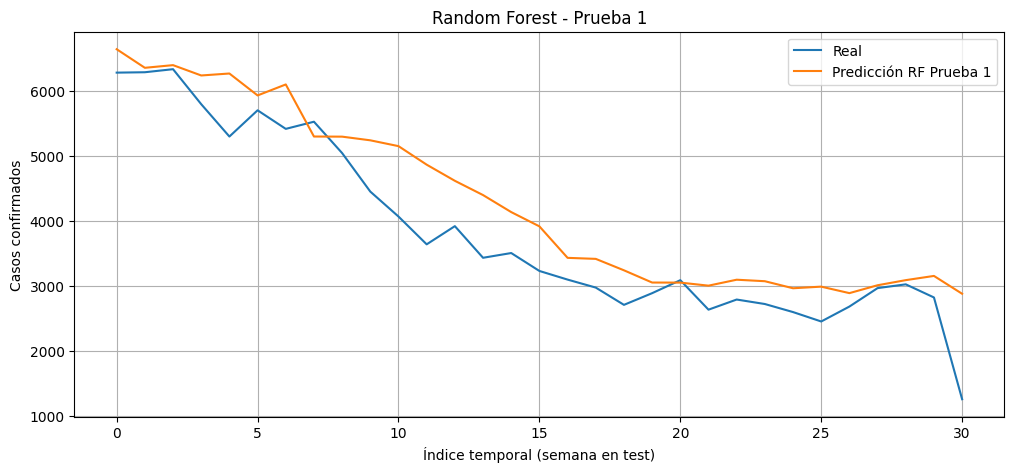

In [47]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="Real")
plt.plot(y_pred_rf_suave, label="Predicción RF Prueba 1")
plt.title("Random Forest - Prueba 1")
plt.xlabel("Índice temporal (semana en test)")
plt.ylabel("Casos confirmados")
plt.legend()
plt.grid(True)
plt.show()


La gráfica muestra la comparación entre los valores reales y las predicciones obtenidas por el modelo Random Forest tras el ajuste moderado de hiperparámetros realizado en la Prueba 1. Aunque la línea de predicciones (en color naranja) conserva la tendencia descendente general de los casos confirmados de dengue, se aprecia una mayor distancia entre ambas curvas, especialmente en los tramos con cambios más bruscos. Esto indica que el modelo ajustado perdió parte de su capacidad para representar con precisión las fluctuaciones semanales, generando predicciones más suaves y menos adaptadas a la variabilidad real.

Este comportamiento se alinea con las métricas obtenidas (MAE = 486.77, R² = 0.7961), las cuales reflejan una ligera degradación del rendimiento respecto al modelo base. En términos prácticos, la reducción en el número de árboles y la limitación de la profundidad afectaron negativamente la capacidad del modelo para capturar patrones complejos del comportamiento del dengue. En conjunto, la gráfica evidencia que la configuración por defecto resultó más adecuada, y que será necesario incrementar la complejidad del modelo en la siguiente prueba para buscar un mejor balance entre precisión y generalización.

#### Gráfico de dispersión (Predicho vs Real)

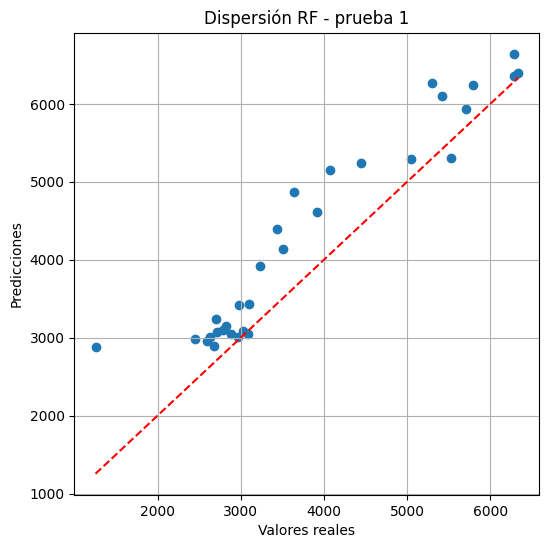

In [48]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf_suave)
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()], 'r--')
plt.title("Dispersión RF - prueba 1")
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.grid(True)
plt.show()


La gráfica de dispersión muestra la relación entre los valores reales y las predicciones generadas por el modelo Random Forest durante la Prueba 1, en la que se aplicó un ajuste moderado de hiperparámetros. Aunque la mayoría de los puntos se alinean de forma general con la línea roja de ajuste perfecto (y = x), se observa una mayor dispersión que en el modelo por defecto, especialmente en los valores intermedios. Esto indica que el modelo perdió precisión al intentar predecir ciertos intervalos de casos, tendiendo a subestimar valores altos y sobreestimar valores bajos.

El comportamiento visual concuerda con los resultados numéricos (MAE = 486.77, R² = 0.7961), que reflejan un ligero deterioro en el desempeño frente al baseline. En conjunto, la gráfica evidencia que la configuración ajustada con menos árboles y menor profundidad redujo la capacidad del modelo para capturar relaciones complejas en los datos, produciendo predicciones más dispersas y menos precisas, lo que confirma que el modelo por defecto estaba mejor equilibrado para este conjunto de datos.

### Prueba 2 - Random Forest

In [49]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

tscv = TimeSeriesSplit(n_splits=5)

rf = RandomForestRegressor(random_state=42)

param_grid_rf_agresivo = {
    'n_estimators':[300,500,700],
    'max_depth':[15,30,None],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4],
    'bootstrap':[True, False]
}

grid_rf_agresivo = GridSearchCV(rf, param_grid_rf_agresivo, cv=tscv, scoring='neg_mean_absolute_error', n_jobs=-1)
grid_rf_agresivo.fit(X_train, y_train)

y_pred_rf_agresivo = grid_rf_agresivo.best_estimator_.predict(X_test)

mae_rf_agresivo = mean_absolute_error(y_test, y_pred_rf_agresivo)
mse_rf_agresivo = mean_squared_error(y_test, y_pred_rf_agresivo)
r2_rf_agresivo = r2_score(y_test, y_pred_rf_agresivo)

mae_rf_agresivo, mse_rf_agresivo, r2_rf_agresivo, grid_rf_agresivo.best_params_


(449.66082181259605,
 329604.1462273581,
 0.8219426535820964,
 {'bootstrap': False,
  'max_depth': 15,
  'min_samples_leaf': 1,
  'min_samples_split': 5,
  'n_estimators': 700})

En la configuración de esta prueba, donde se exploraron mayor número de árboles, mayor profundidad y variaciones más amplias en los criterios de bootstrap y separación de muestras, el modelo logró mejorar su desempeño respecto al baseline por defecto. El MAE disminuyó a 449.66 (vs 482.11 baseline) y el R² aumentó ligeramente a 0.8219, mostrando un mayor ajuste y mejor capacidad predictiva del comportamiento semanal del dengue. El mejor modelo resultó ser aquel con profundidad de 15, 700 árboles, bootstrap desactivado, y mínimos splits más laxos, lo que evidencia que el modelo requiere mayor complejidad para capturar adecuadamente las variaciones temporales. Esto indica que Random Forest sí puede mejorar su desempeño si se incrementa sustancialmente su capacidad de aprendizaje, y demuestra que la manipulación agresiva de hiperparámetros puede generar ganancias reales de predicción en este problema epidemiológico.

#### Gráfico de comparación entre valores reales y predichos

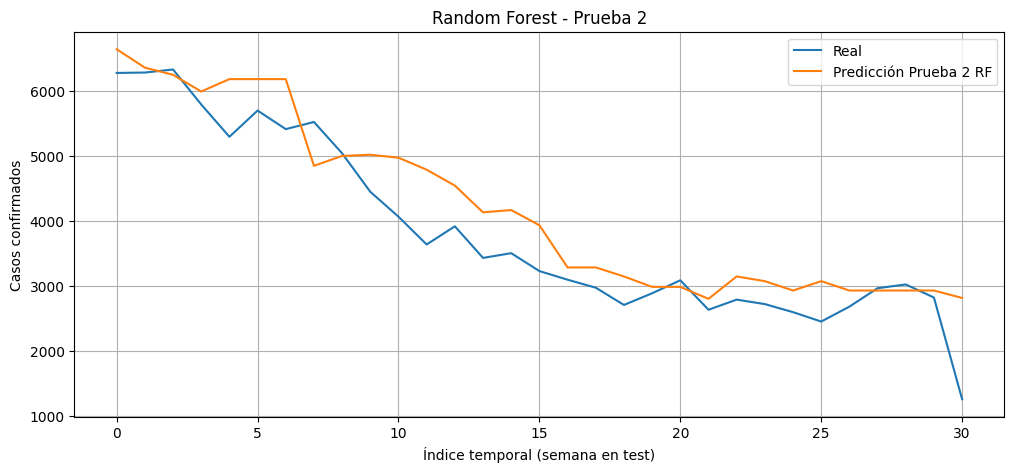

In [50]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="Real")
plt.plot(y_pred_rf_agresivo, label="Predicción Prueba 2 RF")
plt.title("Random Forest - Prueba 2")
plt.xlabel("Índice temporal (semana en test)")
plt.ylabel("Casos confirmados")
plt.legend()
plt.grid(True)
plt.show()


La gráfica muestra la comparación entre los valores reales y las predicciones del modelo Random Forest tras el ajuste más agresivo de hiperparámetros realizado en la Prueba 2. Se observa que la curva de predicciones (en color naranja) sigue de manera más cercana la tendencia descendente de los casos reales, logrando capturar mejor la forma general y reduciendo la distancia entre ambas líneas respecto a las configuraciones anteriores. Aun así, el modelo conserva cierta suavidad en sus estimaciones, lo cual es típico de Random Forest al promediar múltiples árboles, pero sin perder coherencia con los cambios temporales de la serie.

Este comportamiento visual concuerda con las métricas obtenidas (MAE = 449.66, R² = 0.8219), que muestran una mejoría clara respecto al modelo base, evidenciando que el aumento en la profundidad (max_depth = 15) y el número de árboles (700) permitió capturar con mayor precisión las variaciones semanales del dengue. En conjunto, la gráfica confirma que un modelo más complejo y flexible ofrece predicciones más ajustadas y realistas, logrando un equilibrio más favorable entre precisión y generalización en la representación temporal del fenómeno.

#### Gráfico de dispersión (Predicho vs Real)

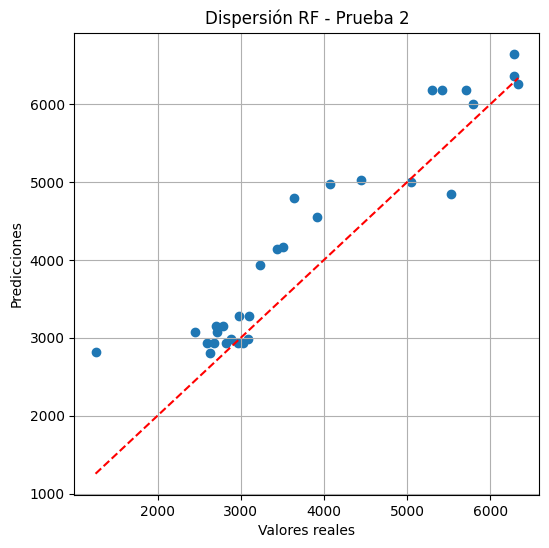

In [51]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf_agresivo)
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()], 'r--')
plt.title("Dispersión RF - Prueba 2")
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.grid(True)
plt.show()


La gráfica de dispersión correspondiente a la Prueba 2 del modelo Random Forest muestra una relación más estrecha entre los valores reales y las predicciones del modelo en comparación con las pruebas anteriores. La mayoría de los puntos se agrupan cerca de la línea roja de ajuste perfecto (y = x), lo que indica que el modelo logró una mayor precisión global y un mejor alineamiento entre los valores observados y estimados. Aun así, se observa una ligera dispersión en los valores intermedios, lo que sugiere pequeñas desviaciones en semanas con fluctuaciones más abruptas.

Este comportamiento es coherente con las métricas obtenidas (MAE = 449.66, R² = 0.8219), que reflejan una mejora notable respecto al modelo base y a la Prueba 1. En conjunto, la gráfica confirma que el incremento de la complejidad del modelo con más árboles, mayor profundidad y parámetros de división más flexibles, permitió capturar con mayor fidelidad la estructura temporal del dengue, ofreciendo un modelo más preciso, robusto y con mejor capacidad de generalización.

### **Conclusión Final del Modelo Random Forest**

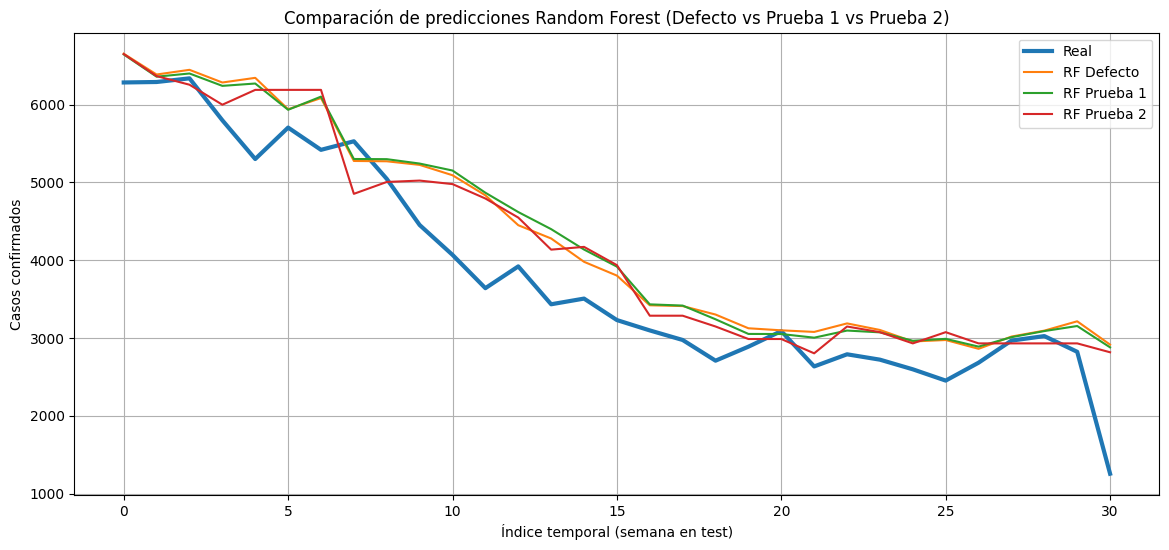

In [52]:
plt.figure(figsize=(14,6))
plt.plot(y_test.values, label="Real", linewidth=3)

plt.plot(y_pred_rf_default, label="RF Defecto")
plt.plot(y_pred_rf_suave, label="RF Prueba 1")
plt.plot(y_pred_rf_agresivo, label="RF Prueba 2")

plt.title("Comparación de predicciones Random Forest (Defecto vs Prueba 1 vs Prueba 2)")
plt.xlabel("Índice temporal (semana en test)")
plt.ylabel("Casos confirmados")
plt.legend()
plt.grid(True)
plt.show()


El Random Forest mostró un rendimiento aceptable modelando la serie temporal semanal del dengue, con un nivel de ajuste considerable desde su configuración por defecto. Sin embargo, la manipulación de parámetros evidencia que el modelo necesita una mayor complejidad para mejorar. La prueba 1  empeoró las métricas, lo cual indica que reducir profundidad y número de árboles no es adecuado para este problema temporal. Por el contrario, la prueba 2 mejoró el MAE y elevó el R² respecto al baseline por defecto, demostrando que incrementar profundidad, número de árboles y modificar bootstrap permite capturar mejor las fluctuaciones del dengue.

**Mejor versión del RF**

La mejor prueba es numero 2, porque obtuvo el MAE más bajo y mejor capacidad predictiva. Por lo tanto, para la comparación final de modelos, se seleccionará Random Forest Prueba 2 como la versión oficial del modelo RF. 

### **Modelo 4 — Red Neuronal MLP (Multi-Layer Perceptron)**

Las redes neuronales tipo MLP (Multi-Layer Perceptron) son modelos de aprendizaje supervisado basados en capas densamente conectadas, donde cada neurona transforma la entrada mediante una función de activación no lineal. Estos modelos son adecuados para capturar relaciones no lineales entre los valores pasados de la serie temporal (lags, medias móviles y estacionalidad) y los casos futuros de dengue.

En este trabajo, el MLP se considera como una red neuronal “simple”, con pocas capas ocultas y una arquitectura relativamente compacta. Por este motivo, se analiza primero su desempeño como modelo base y posteriormente, mediante técnicas de optimización con GridSearchCV, se exploran configuraciones más adecuadas para este tipo de datos.

### MLP por defecto

In [53]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mlp_default = MLPRegressor(
    random_state=42,
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    learning_rate='adaptive',
    learning_rate_init=0.003,
    max_iter=8000,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=30,
    alpha=0.0005
)

mlp_default.fit(X_train_scaled, y_train)
y_pred_mlp_default = mlp_default.predict(X_test_scaled)

mae_mlp_default = mean_absolute_error(y_test, y_pred_mlp_default)
mse_mlp_default = mean_squared_error(y_test, y_pred_mlp_default)
r2_mlp_default  = r2_score(y_test, y_pred_mlp_default)

mae_mlp_default, mse_mlp_default, r2_mlp_default


(1199.3677427108946, 1606936.657048806, 0.1319075312286896)

El modelo Multilayer Perceptron (MLP) en su configuración por defecto obtuvo un MAE de 1199.37, un MSE de 1,606,936.66 y un R² de 0.1319, lo que refleja un bajo desempeño predictivo y una capacidad limitada para representar la dinámica temporal del dengue. Este resultado sugiere que, con los parámetros predeterminados, la red neuronal no logró converger adecuadamente ni capturar las relaciones no lineales presentes en los datos, posiblemente debido a una falta de ajuste en la estructura de la red, la tasa de aprendizaje o el número de iteraciones. En comparación con los modelos lineales y basados en árboles, el MLP por defecto presenta un error considerablemente mayor y un R² muy bajo, evidenciando que requiere una optimización más profunda de sus hiperparámetros para alcanzar un rendimiento competitivo en este tipo de problema temporal.

#### Gráfico de comparación entre valores reales y predichos

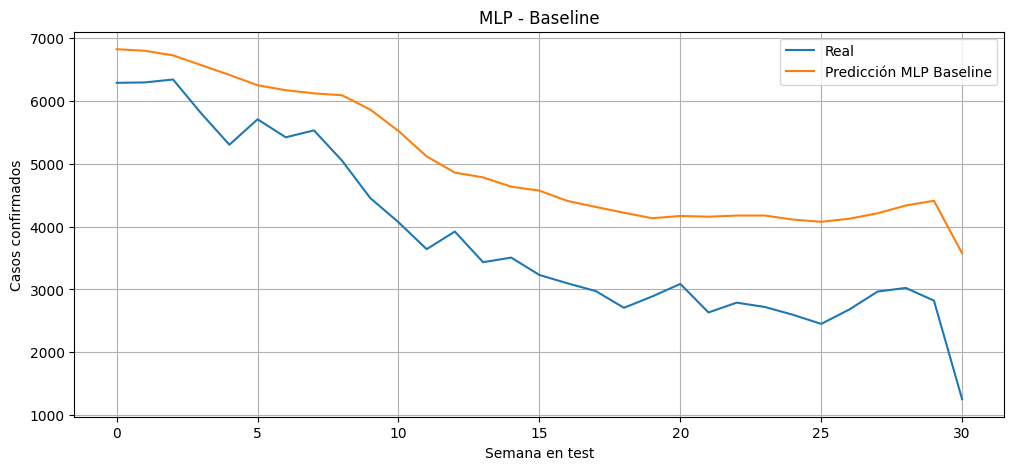

In [54]:
# Serie temporal
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="Real")
plt.plot(y_pred_mlp_default, label="Predicción MLP Baseline")
plt.title("MLP - Baseline")
plt.xlabel("Semana en test")
plt.ylabel("Casos confirmados")
plt.legend()
plt.grid(True)
plt.show()

La gráfica muestra la comparación entre los valores reales y las predicciones generadas por el modelo MLP (Multilayer Perceptron) en su configuración por defecto. Se observa que la línea de predicción (en color naranja) mantiene una forma descendente similar a la de los valores reales, pero con una sobreestimación constante en casi todo el rango temporal, lo que indica que el modelo no logró ajustarse correctamente a la escala de los datos. Este comportamiento sugiere que el MLP, sin un ajuste de hiperparámetros, no alcanzó una convergencia adecuada durante el entrenamiento y presenta dificultades para capturar las fluctuaciones semanales del dengue.

Las métricas obtenidas (MAE = 1199.37, MSE = 1,606,936.66, R² = 0.1319) confirman un bajo poder predictivo, evidenciando que el modelo, en su versión base, no logra representar de forma precisa la dinámica temporal del fenómeno. En conjunto, la gráfica refleja un modelo que tiende a generar predicciones suavizadas y alejadas de los valores reales, lo que pone de manifiesto la necesidad de optimizar su arquitectura y parámetros de entrenamiento para mejorar su capacidad de aprendizaje y ajuste.

#### Gráfico de dispersión (Predicho vs Real)

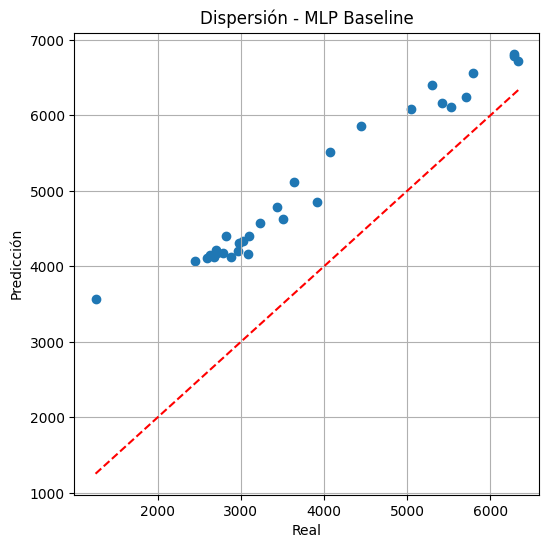

In [55]:
# Dispersión
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_mlp_default)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.title("Dispersión - MLP Baseline")
plt.xlabel("Real")
plt.ylabel("Predicción")
plt.grid(True)
plt.show()

La gráfica de dispersión correspondiente al modelo MLP en su configuración por defecto muestra la relación entre los valores reales y las predicciones generadas. Se observa que la mayoría de los puntos se encuentran por encima de la línea roja de ajuste perfecto (y = x), lo que indica una tendencia sistemática a sobreestimar los valores reales. Además, los puntos presentan una dispersión considerable, especialmente en los valores intermedios, reflejando una falta de precisión y una pobre correlación entre las predicciones y los datos observados.

Este patrón es coherente con las métricas obtenidas (MAE = 1199.37, MSE = 1,606,936.66, R² = 0.1319), que evidencian un bajo desempeño global del modelo. El MLP, en su versión base, no logró capturar adecuadamente la estructura temporal ni la magnitud de los casos de dengue, lo que sugiere que su arquitectura o los parámetros de entrenamiento requieren ajustes significativos. En conjunto, la gráfica revela que el modelo produce estimaciones excesivamente altas y poco alineadas con los valores reales, confirmando que el MLP necesita una optimización más profunda para mejorar su capacidad de generalización y predicción.

### Prueba 1 - MLP

In [57]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

tscv = TimeSeriesSplit(n_splits=3) 

mlp = MLPRegressor(
    max_iter=10000,              
    early_stopping=True,
    validation_fraction=0.15,
    learning_rate='adaptive',
    random_state=42
)

param_grid_mlp = {
    'hidden_layer_sizes': [(64,), (128,), (64,32), (128,64,32)],
    'alpha': [0.0001, 0.0005, 0.001, 0.01]
}

grid_mlp = GridSearchCV(
    estimator=mlp,
    param_grid=param_grid_mlp,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1                   
)

grid_mlp.fit(X_train_scaled, y_train)

y_pred_mlp_suave = grid_mlp.best_estimator_.predict(X_test_scaled)

mae_mlp = mean_absolute_error(y_test,y_pred_mlp_suave)
mse_mlp = mean_squared_error(y_test, y_pred_mlp_suave)
r2_mlp = r2_score(y_test, y_pred_mlp_suave)

mae_mlp, mse_mlp, r2_mlp, grid_mlp.best_params_


(895.7622076793523,
 901614.6505986986,
 0.5129335780067186,
 {'alpha': 0.01, 'hidden_layer_sizes': (128, 64, 32)})

La Prueba 1 del modelo Multilayer Perceptron (MLP) incorporó un ajuste de hiperparámetros mediante GridSearchCV con validación cruzada temporal (TimeSeriesSplit), buscando mejorar la convergencia y capacidad predictiva del modelo base. En esta prueba, se exploraron diferentes arquitecturas de red y valores de regularización (alpha), identificándose como mejor configuración la estructura (128, 64, 32) con alpha = 0.01.

Los resultados obtenidos muestran una mejora significativa respecto al modelo por defecto, alcanzando un MAE de 895.76, MSE de 901,614.65 y un R² de 0.5129. Esto indica que el MLP logró capturar una mayor proporción de la variabilidad temporal de los casos de dengue, reduciendo el error promedio en comparación con la configuración inicial. Sin embargo, aunque el desempeño mejoró de forma notable, el modelo aún no alcanza la precisión de los métodos basados en árboles o la regresión lineal, mostrando cierta tendencia a suavizar las predicciones y dificultades para representar picos abruptos en la serie.

#### Gráfico de comparación entre valores reales y predichos

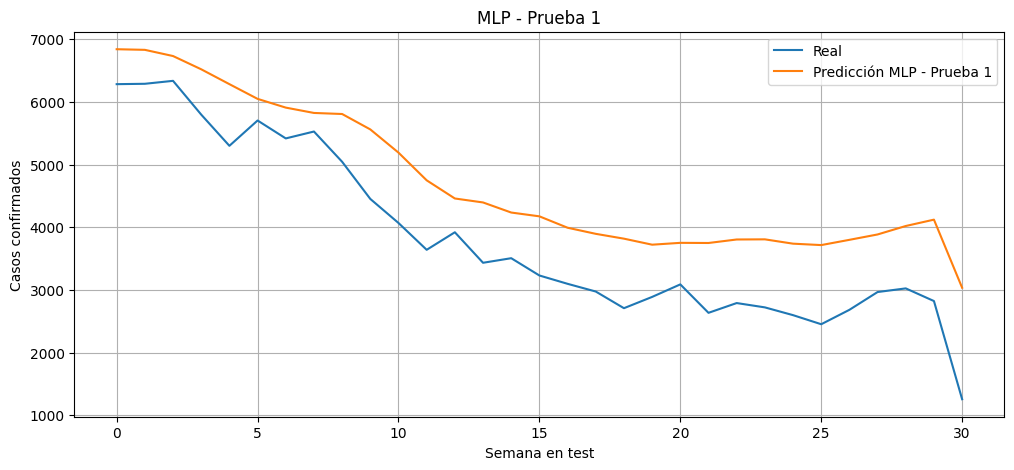

In [58]:
# Serie temporal
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="Real")
plt.plot(y_pred_mlp_suave, label="Predicción MLP - Prueba 1")
plt.title("MLP - Prueba 1")
plt.xlabel("Semana en test")
plt.ylabel("Casos confirmados")
plt.legend()
plt.grid(True)
plt.show()


La gráfica muestra la comparación entre los valores reales y las predicciones generadas por el modelo MLP (Multilayer Perceptron) tras el ajuste de hiperparámetros realizado en la Prueba 1. Se observa que la curva de predicción (en color naranja) sigue de forma más coherente la tendencia descendente de los casos de dengue en comparación con el modelo por defecto, aunque mantiene una sobreestimación sistemática en casi todo el rango temporal. Esto indica que el MLP ajustado logró una mejor convergencia y una mayor estabilidad en las predicciones, pero todavía presenta dificultades para capturar con precisión la magnitud real de los valores, especialmente en los puntos de descenso más pronunciado.

Este comportamiento concuerda con las métricas obtenidas (MAE = 895.76, MSE = 901,614.65, R² = 0.5129), que evidencian una mejora considerable respecto al modelo base, aunque el desempeño aún se mantiene moderado en términos de precisión. En conjunto, la gráfica refleja que la optimización de hiperparámetros permitió al MLP aprender mejor la tendencia temporal general del dengue, pero sigue siendo necesario explorar arquitecturas más complejas o técnicas de regularización adicionales para mejorar la capacidad del modelo de representar los picos y variaciones locales de la serie.

#### Gráfico de dispersión (Predicho vs Real)

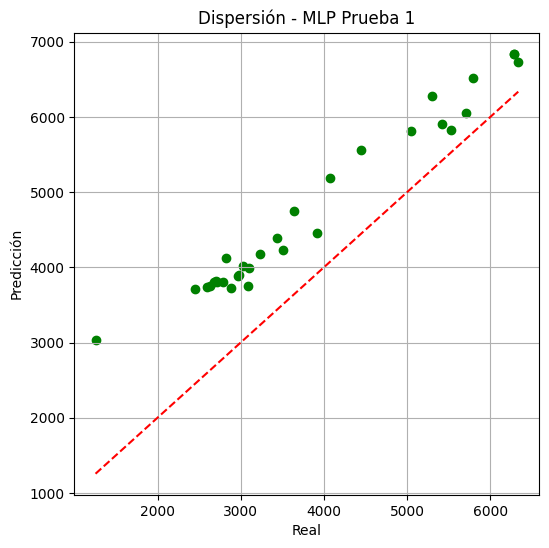

In [59]:
# Dispersión
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_mlp_suave, color="green")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.title("Dispersión - MLP Prueba 1")
plt.xlabel("Real")
plt.ylabel("Predicción")
plt.grid(True)
plt.show()

La gráfica de dispersión correspondiente a la Prueba 1 del modelo MLP muestra una relación más estrecha entre los valores reales y las predicciones que la observada en el modelo base, aunque aún persiste una tendencia a la sobreestimación, especialmente en los valores intermedios. La mayoría de los puntos se concentran por encima de la línea roja de ajuste perfecto (y = x), lo que indica que el modelo predice sistemáticamente valores más altos que los reales. Sin embargo, la distribución de los puntos es más compacta que en la configuración por defecto, reflejando una mejor correlación entre las predicciones y los valores observados.

Este comportamiento está alineado con las métricas obtenidas (MAE = 895.76, MSE = 901,614.65, R² = 0.5129), las cuales confirman una mejora significativa en la capacidad explicativa del modelo respecto al baseline. En conjunto, la gráfica evidencia que el ajuste de hiperparámetros permitió al MLP aprender de manera más estable la estructura general de los datos, aunque todavía presenta limitaciones en la magnitud y precisión de las estimaciones, lo que sugiere la necesidad de una arquitectura más compleja o un mayor número de épocas de entrenamiento para mejorar su ajuste final.

### Prueba 2 — MLP

In [60]:
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Validación temporal
tscv = TimeSeriesSplit(n_splits=3)  

# Configuración del MLP
mlp2 = MLPRegressor(
    max_iter=3000,  
    early_stopping=True,
    n_iter_no_change=10, 
    validation_fraction=0.15,
    solver='adam', 
    random_state=42
)

# Grid de parámetros optimizado
param_grid_mlp_agresivo = {
    'hidden_layer_sizes': [
        (64, 32),
        (128, 64)
    ], 
    'alpha': [0.0001, 0.001],
    'learning_rate': ['adaptive']  
}

# GridSearch optimizado
grid_mlp_agresivo = GridSearchCV(
    estimator=mlp2,
    param_grid=param_grid_mlp_agresivo,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,  
    verbose=2  
)

# Entrenamiento
grid_mlp_agresivo.fit(X_train_scaled, y_train)

# Predicciones
y_pred_mlp_agresivo = grid_mlp_agresivo.best_estimator_.predict(X_test_scaled)

# Evaluación
mae_mlp_agresivo = mean_absolute_error(y_test, y_pred_mlp_agresivo)
mse_mlp_agresivo = mean_squared_error(y_test, y_pred_mlp_agresivo)
r2_mlp_agresivo  = r2_score(y_test, y_pred_mlp_agresivo)

mae_mlp_agresivo, mse_mlp_agresivo, r2_mlp_agresivo, grid_mlp_agresivo.best_params_


Fitting 3 folds for each of 4 candidates, totalling 12 fits


(934.7000915687139,
 1075986.8231245016,
 0.41873498650097773,
 {'alpha': 0.001,
  'hidden_layer_sizes': (128, 64),
  'learning_rate': 'adaptive'})

La Prueba 2 del modelo MLP tuvo como objetivo explorar una configuración más compleja mediante un mayor número de neuronas por capa y un control más fino de la regularización, buscando mejorar la capacidad de generalización del modelo frente a la serie temporal del dengue. Sin embargo, los resultados obtenidos (MAE = 934.70, MSE = 1,075,986.82, R² = 0.4187) indican que el desempeño fue inferior al alcanzado en la Prueba 1 (MAE ≈ 895.76, R² ≈ 0.51).

A pesar de aumentar la complejidad de la red (estructura de capas (128, 64) y menor tasa de regularización α = 0.001), el modelo no logró capturar de manera más precisa la dinámica semanal de los casos de dengue, mostrando incluso una menor capacidad explicativa y mayor error medio. Esto sugiere que el MLP comenzó a sobreajustarse parcialmente al conjunto de entrenamiento o que la arquitectura seleccionada no fue suficiente para representar adecuadamente las relaciones temporales y no lineales del fenómeno.


#### Gráfico de comparación entre valores reales y predichos

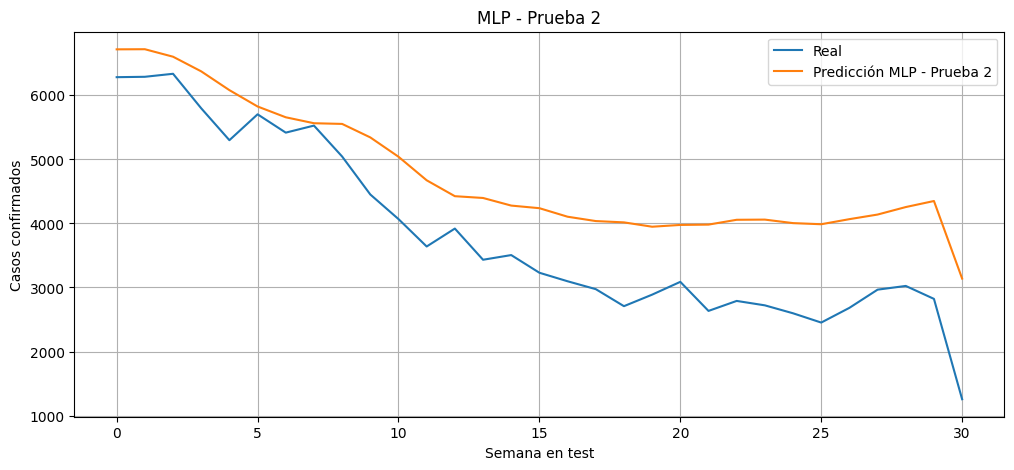

In [124]:
# Serie temporal
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="Real")
plt.plot(y_pred_mlp_agresivo, label="Predicción MLP - Prueba 2")
plt.title("MLP - Prueba 2")
plt.xlabel("Semana en test")
plt.ylabel("Casos confirmados")
plt.legend()
plt.grid(True)
plt.show()

En la gráfica de la Prueba 2 del modelo MLP, se observa que la línea de predicciones (naranja) sigue una trayectoria más suavizada y menos variable que los valores reales (azul). Aunque el modelo logra capturar la tendencia general descendente de los casos de dengue a lo largo del tiempo, su comportamiento muestra una subestimación de los picos bajos y una sobreestimación de los valores más altos, lo que indica que el MLP tiende a generar predicciones más estables pero menos sensibles a los cambios bruscos semanales.

Esta falta de respuesta ante las fluctuaciones reales sugiere que la red, a pesar de contar con una mayor complejidad estructural (capas de 128 y 64 neuronas), no consiguió adaptarse a la naturaleza no lineal y ruidosa de la serie temporal, produciendo salidas más generalizadas que no reflejan adecuadamente los extremos. En conjunto, la gráfica evidencia que el modelo mantiene una dirección coherente con la tendencia real, pero su capacidad de ajuste fino es limitada, lo cual concuerda con las métricas obtenidas (MAE elevado y R² moderado).

#### Gráfico de dispersión (Predicho vs Real)

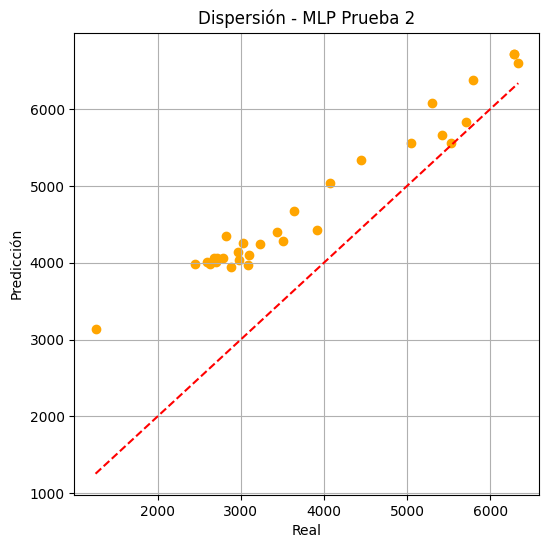

In [125]:
# Dispersión
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_mlp_agresivo, color="orange")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.title("Dispersión - MLP Prueba 2")
plt.xlabel("Real")
plt.ylabel("Predicción")
plt.grid(True)
plt.show()

En la gráfica de dispersión del MLP Prueba 2, se aprecia que los puntos se agrupan por encima de la línea roja de ajuste perfecto (y = x), lo cual indica una tendencia del modelo a sobreestimar los valores reales de casos de dengue. Aunque existe una correlación general positiva entre los valores reales y los predichos —lo que demuestra que el modelo logra capturar la dirección global de la tendencia—, la dispersión de los puntos respecto a la línea ideal revela una falta de precisión significativa, especialmente en los valores bajos y medios.

Esto refleja que el MLP mantiene un sesgo sistemático hacia valores más altos, lo que se traduce en errores mayores y un coeficiente de determinación (R² ≈ 0.42) moderado. En síntesis, el modelo muestra una capacidad limitada para ajustar correctamente la magnitud real de los casos semanales, produciendo estimaciones consistentes pero excesivamente suavizadas, lo que sugiere que, pese al tuning de hiperparámetros, el aprendizaje del patrón temporal aún es insuficiente.

### **Conclusión Final del Modelo MLP**

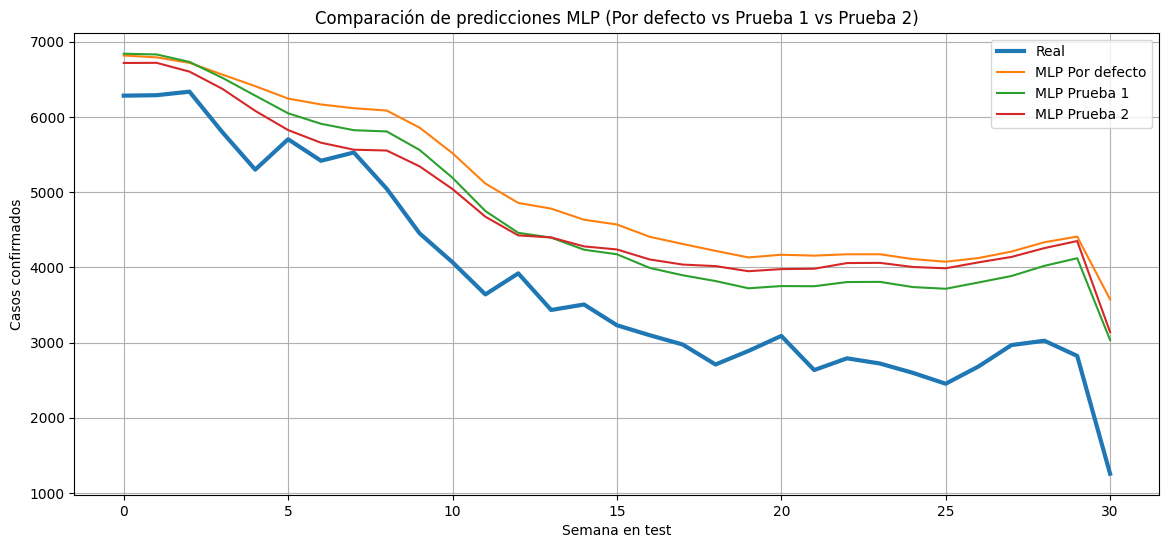

In [63]:
plt.figure(figsize=(14,6))
plt.plot(y_test.values, label="Real", linewidth=3)

plt.plot(y_pred_mlp_default, label="MLP Por defecto")
plt.plot(y_pred_mlp_suave, label="MLP Prueba 1")
plt.plot(y_pred_mlp_agresivo, label="MLP Prueba 2")

plt.title("Comparación de predicciones MLP (Por defecto vs Prueba 1 vs Prueba 2)")
plt.xlabel("Semana en test")
plt.ylabel("Casos confirmados")
plt.legend()
plt.grid(True)
plt.show()


La gráfica comparativa del modelo MLP (Baseline, Prueba 1 y Prueba 2) evidencia que las tres configuraciones siguen una tendencia general parecida, aunque difieren en el nivel de ajuste frente a los valores reales. El modelo por defecto (Baseline) se mantiene claramente por encima de la serie observada, lo que refleja una marcada sobreestimación de los casos de dengue y una incapacidad para adaptarse a las variaciones más pronunciadas. Su comportamiento excesivamente suavizado indica que, en su configuración inicial, el MLP no logra capturar la dinámica temporal de la serie con suficiente precisión.

En la Prueba 1, tras aplicar un ajuste moderado de hiperparámetros con una arquitectura (128, 64, 32) y una regularización alpha = 0.01, el modelo mostró una mejora notable (MAE ≈ 895.7, R² ≈ 0.51). Las predicciones se acercaron más a los valores reales, reduciendo parte del sesgo y ofreciendo una representación más coherente de la tendencia semanal del dengue. Aunque el modelo aún tiende a suavizar los cambios abruptos, esta configuración demostró un mejor equilibrio entre precisión y generalización, siendo la más efectiva entre las tres.

Por su parte, la Prueba 2, con una estructura más profunda (128, 64) y menor regularización, no logró mejorar el rendimiento (MAE ≈ 934.7, R² ≈ 0.42) y mantuvo la tendencia a sobreestimar los casos. En conjunto, los resultados muestran que, aunque el MLP puede aprender parcialmente la tendencia general, no supera a los modelos lineales ni a los basados en árboles, lo que sugiere que su arquitectura actual no logra capturar de forma eficiente las dependencias temporales presentes en la evolución semanal del dengue.

En conjunto, los resultados confirman que el MLP Prueba 1 fue la configuración más efectiva, alcanzando el mejor equilibrio entre precisión y generalización. Sin embargo, el modelo en general no logra superar el desempeño de enfoques más simples como la regresión lineal o los árboles de decisión, lo que sugiere que su arquitectura actual no captura adecuadamente las dependencias temporales presentes en la dinámica semanal del dengue.

### **Modelo 5 — Red Neuronal DNN (Deep Neural Network)**

Las redes neuronales profundas (DNN) son una extensión del modelo Multilayer Perceptron (MLP) que incorporan un mayor número de capas ocultas y neuronas, lo cual amplía su capacidad para aprender relaciones no lineales y patrones complejos en los datos. Este tipo de modelo resulta particularmente útil en contextos donde las dependencias entre variables no son evidentes o presentan comportamientos dinámicos, como ocurre con la evolución temporal de los casos de dengue.

En este trabajo, la DNN se implementó utilizando Keras, una API de alto nivel basada en TensorFlow, que permite definir arquitecturas personalizadas, aplicar funciones de activación, seleccionar optimizadores y emplear técnicas de regularización, como Dropout, para mitigar el sobreajuste. A diferencia de los modelos basados en scikit-learn, no se utilizó GridSearchCV para la optimización de hiperparámetros, debido a que este método resulta ineficiente en redes neuronales profundas, donde cada configuración requiere un proceso de entrenamiento costoso y prolongado. En su lugar, se optó por un ajuste experimental manual, realizando pruebas controladas con diferentes arquitecturas y tasas de aprendizaje. Este enfoque permitió analizar el comportamiento del modelo y ajustar sus parámetros de manera más flexible y eficiente. Alternativamente, herramientas como Keras Tuner u Optuna podrían emplearse para una búsqueda más automatizada y escalable en futuras implementaciones.

La Prueba 1 (DNN Suave) utilizó una arquitectura moderadamente profunda con capas densas de 128, 128 y 64 neuronas, una tasa de dropout de 0.15 y una tasa de aprendizaje de 0.0008. Este diseño buscó equilibrar la capacidad de aprendizaje y la estabilidad, reduciendo el riesgo de sobreajuste. En contraste, la Prueba 2 (DNN Agresiva) exploró una arquitectura más compleja con capas de 256, 128, 64 y 32 neuronas, una regularización más fuerte (dropout de 0.2) y una tasa de aprendizaje más baja (0.0005), con el objetivo de evaluar si un aumento sustancial en la profundidad y la complejidad de la red podía mejorar la precisión y generalización del modelo.

#### Librerias necesarias para DNN

In [64]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import Sequential, Input
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


#### División de entrenamiento y validación

In [65]:
# Se separa una parte del conjunto de entrenamiento para validación explícita (20%)
X_train2, X_valid, y_train2, y_valid = train_test_split(X_train_scaled, y_train, test_size=0.2, random_state=42)

### DNN por defecto

In [67]:
dnn_baseline = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),  
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dropout(0.1),  # regularización ligera para evitar sobreajuste
    Dense(1, activation='linear')  # salida lineal para regresión
])

# Compilación del modelo
dnn_baseline.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

# EarlyStopping para detener el entrenamiento cuando no haya mejora
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=20, 
    restore_best_weights=True
)

# Entrenamiento del modelo
history_dnn_base = dnn_baseline.fit(
    X_train2, y_train2,
    validation_data=(X_valid, y_valid),
    epochs=500,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

#Predicciones
y_pred_dnn_base = dnn_baseline.predict(X_test_scaled).flatten()

#Evaluación del modelo
mae_dnn_base = mean_absolute_error(y_test, y_pred_dnn_base)
mse_dnn_base = mean_squared_error(y_test, y_pred_dnn_base)
r2_dnn_base  = r2_score(y_test, y_pred_dnn_base)

mae_dnn_base, mse_dnn_base, r2_dnn_base

Epoch 1/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 92ms/step - loss: 8277164.0000 - mae: 2270.1736 - val_loss: 5043949.0000 - val_mae: 1780.7336
Epoch 2/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 8274114.0000 - mae: 2269.6794 - val_loss: 5042057.0000 - val_mae: 1780.3075
Epoch 3/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 8270535.0000 - mae: 2269.1326 - val_loss: 5039443.5000 - val_mae: 1779.7225
Epoch 4/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 8265527.5000 - mae: 2268.3452 - val_loss: 5035577.5000 - val_mae: 1778.8785
Epoch 5/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 8259062.0000 - mae: 2267.2798 - val_loss: 5029857.0000 - val_mae: 1777.6293
Epoch 6/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 8248202.5000 - mae: 2265.5449 - val_loss: 5021323.0000 - val_mae: 1775.7410
Epoch 7/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 8232446.5000 - mae: 2263.0952 - val_loss: 5008558.5000 - val_mae: 1772.8953
Epoch 8/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 8209

(1202.2782651839718, 1635914.750514817, 0.1162531091412663)

El modelo Deep Neural Network (DNN) en su configuración por defecto obtuvo un MAE de 1202.28, un MSE de 1,635,914.75 y un R² de 0.1162, lo que refleja un desempeño bajo y una capacidad limitada para representar la variabilidad semanal de los casos de dengue. A pesar de contar con una arquitectura más profunda —con tres capas densas (128, 64 y 32 neuronas) y una ligera regularización Dropout—, el modelo no logró captar de manera efectiva las relaciones entre las variables de entrada y la variable objetivo.

El bajo valor de R² indica que la red apenas explica el 11% de la variabilidad de los datos, lo que sugiere problemas de convergencia o subajuste, posiblemente asociados a una configuración de hiperparámetros poco adecuada o a la falta de un volumen de datos suficiente para aprovechar la complejidad de la red. En comparación con los modelos previos (como la regresión lineal, el árbol de decisión o incluso el MLP ajustado), la DNN muestra un error mayor y menor poder predictivo, evidenciando que una arquitectura más profunda no necesariamente mejora el rendimiento cuando no se optimizan correctamente los parámetros ni se dispone de una estructura temporal robusta en los datos.

#### Gráfica de curvas de entrenamiento  (error de entrenamiento vs validación)

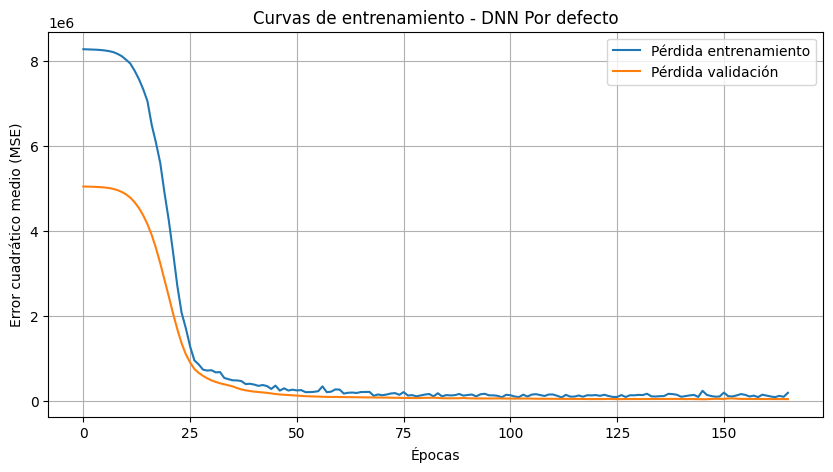

In [69]:
# Permite observar el comportamiento del error en entrenamiento y validación
plt.figure(figsize=(10,5))
plt.plot(history_dnn_base.history['loss'], label='Pérdida entrenamiento')
plt.plot(history_dnn_base.history['val_loss'], label='Pérdida validación')
plt.title("Curvas de entrenamiento - DNN Por defecto")
plt.xlabel("Épocas")
plt.ylabel("Error cuadrático medio (MSE)")
plt.legend()
plt.grid(True)
plt.show()


La gráfica de curvas de entrenamiento del modelo DNN por defecto muestra una convergencia rápida tanto en la pérdida de entrenamiento como en la de validación, estabilizándose ambas alrededor de la época 30. Al inicio, la pérdida de entrenamiento presenta valores muy altos, superiores a 8×10⁶, pero desciende abruptamente conforme el modelo ajusta sus pesos. De manera similar, la pérdida de validación disminuye rápidamente y se mantiene paralela a la de entrenamiento, lo que indica que no hay signos evidentes de sobreajuste, ya que ambas curvas evolucionan de forma coherente y sin divergencias notables.

Sin embargo, aunque las curvas reflejan un aprendizaje estable y una buena convergencia técnica, los resultados finales del modelo (R² ≈ 0.12) demuestran que la red no logra generalizar bien sobre los datos de prueba. Esto sugiere que, a pesar de minimizar el error interno, el modelo no está capturando las relaciones subyacentes relevantes en la serie temporal del dengue. En otras palabras, el DNN logra aprender patrones internos de los datos de entrenamiento, pero estos no se traducen en una mejora real del poder predictivo, probablemente debido a una arquitectura poco adecuada para la estructura temporal del problema o a una falta de ajuste en los hiperparámetros de aprendizaje.

#### Gráfico de comparación entre valores reales y predichos

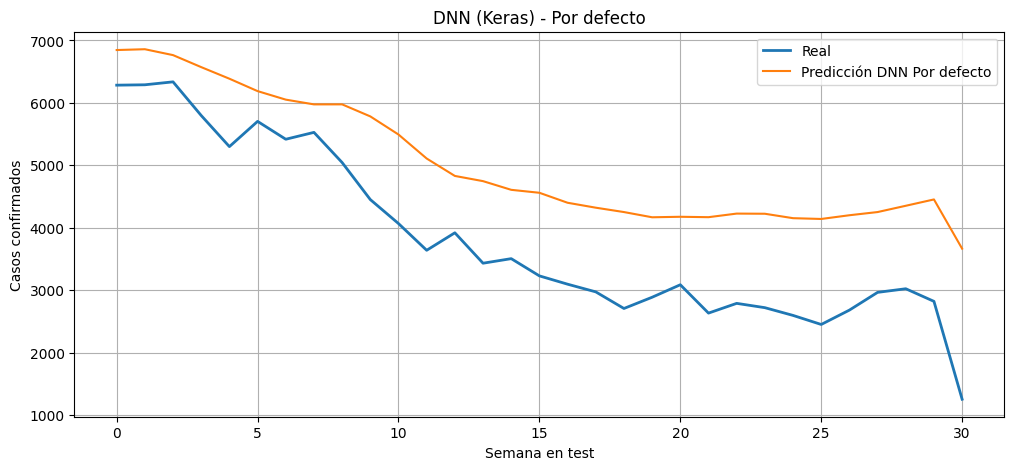

In [71]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="Real", linewidth=2)
plt.plot(y_pred_dnn_base, label="Predicción DNN Por defecto")
plt.title("DNN (Keras) - Por defecto")
plt.xlabel("Semana en test")
plt.ylabel("Casos confirmados")
plt.legend()
plt.grid(True)
plt.show()

La gráfica del modelo DNN (Keras) — Por defecto muestra una discrepancia clara entre las predicciones y los valores reales de los casos de dengue. La red neuronal tiende a sobreestimar de forma constante la cantidad de casos confirmados, ubicando su curva de predicción por encima de la serie observada durante casi todo el periodo de prueba. Aunque la forma general de la tendencia es similar, ambas muestran una disminución progresiva a lo largo de las semanas, la DNN no logra reproducir la magnitud real de los descensos ni las fluctuaciones más pronunciadas.

Este comportamiento refleja que el modelo, en su configuración base, aprendió parcialmente la tendencia global de la serie temporal, pero no capturó adecuadamente las variaciones locales ni los cambios abruptos. El resultado está alineado con sus métricas de rendimiento (MAE ≈ 1202.28, R² ≈ 0.12), que evidencian un ajuste deficiente y una capacidad predictiva limitada. En conjunto, la gráfica confirma que la DNN baseline mantiene un sesgo sistemático de sobreestimación y un aprendizaje superficial del patrón temporal, lo que sugiere la necesidad de un ajuste más profundo de hiperparámetros o el uso de arquitecturas más especializadas para datos secuenciales.

#### Gráfico de dispersión (Predicho vs Real)

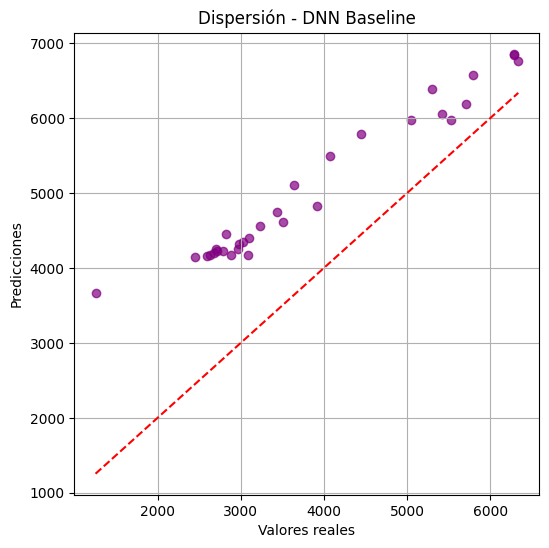

In [72]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_dnn_base, alpha=0.7, color="purple")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.title("Dispersión - DNN Baseline")
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.grid(True)
plt.show()

La gráfica de dispersión del modelo DNN Por defecto muestra una tendencia clara a la sobreestimación de los valores predichos. La mayoría de los puntos se encuentran por encima de la línea roja de ajuste perfecto (y = x), lo que indica que el modelo predice sistemáticamente más casos de dengue de los que realmente ocurrieron. Aunque existe cierta correlación entre los valores reales y las predicciones, la dispersión de los puntos revela una precisión limitada y una falta de ajuste fino a la variabilidad real de los datos.

Este comportamiento es coherente con las métricas obtenidas (MAE ≈ 1202.28, R² ≈ 0.12), que muestran un bajo poder explicativo y un error elevado. En conjunto, la gráfica confirma que el modelo DNN en su configuración por defecto solo logra capturar la tendencia general de los casos de dengue, pero no reproduce adecuadamente la magnitud de los valores ni las fluctuaciones semanales, lo que evidencia una necesidad de ajuste más profundo y optimización de parámetros.

### Prueba 1 - DNN

In [73]:
dnn_suave = Sequential([
    Input(shape=(X_train_scaled.shape[1],)), 
    Dense(128, activation='relu'),
    Dense(128, activation='relu'),
    Dropout(0.15),
    Dense(64, activation='relu'),
    Dense(1, activation='linear')
])

dnn_suave.compile(optimizer=Adam(learning_rate=0.0008), loss='mse', metrics=['mae'])

early_stop_suave = EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True)

history_dnn_suave = dnn_suave.fit(
    X_train2, y_train2,
    validation_data=(X_valid, y_valid),
    epochs=600,
    batch_size=16,
    callbacks=[early_stop_suave],
    verbose=1
)

# Predicciones y evaluación
y_pred_dnn_suave = dnn_suave.predict(X_test_scaled).flatten()
mae_dnn_suave = mean_absolute_error(y_test, y_pred_dnn_suave)
mse_dnn_suave = mean_squared_error(y_test, y_pred_dnn_suave)
r2_dnn_suave  = r2_score(y_test, y_pred_dnn_suave)
mae_dnn_suave, mse_dnn_suave, r2_dnn_suave


Epoch 1/600
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 89ms/step - loss: 8275029.0000 - mae: 2269.8174 - val_loss: 5041706.0000 - val_mae: 1780.1954
Epoch 2/600
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 8269692.0000 - mae: 2268.9182 - val_loss: 5037568.5000 - val_mae: 1779.1644
Epoch 3/600
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 8262722.5000 - mae: 2267.6729 - val_loss: 5031128.5000 - val_mae: 1777.5710
Epoch 4/600
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 8251585.5000 - mae: 2265.6377 - val_loss: 5020890.0000 - val_mae: 1775.0259
Epoch 5/600
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 8234293.5000 - mae: 2262.4351 - val_loss: 5003476.5000 - val_mae: 1770.8003
Epoch 6/600
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 8204004.5000 - mae: 2257.1655 - val_loss: 4975015.5000 - val_mae: 1764.0216
Epoch 7/600
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 8153453.5000 - mae: 2248.5417 - val_loss: 4930492.5000 - val_mae: 1753.5084
Epoch 8/600
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 8076

(1208.6917212701612, 1708427.5007834896, 0.07708058039098231)

El modelo DNN Prueba 1 (DNN Suave) presentó un rendimiento limitado, con un MAE de 1208.69, un MSE de 1,708,427.50 y un R² de apenas 0.077, lo que indica que la red logró explicar menos del 8% de la variabilidad de los casos reales de dengue. Estos resultados muestran que, a pesar de la arquitectura más profunda y del uso de regularización (dropout de 0.15), el modelo no consiguió mejorar el desempeño obtenido en la configuración por defecto.

Este comportamiento sugiere que la red no alcanzó una representación efectiva de los patrones temporales del dengue, probablemente debido a un subajuste, es decir, una capacidad insuficiente para aprender las relaciones entre las variables históricas y las predicciones. Aunque la implementación de early stopping evitó el sobreentrenamiento, la combinación de hiperparámetros (tasa de aprendizaje, número de neuronas y profundidad) no fue suficiente para capturar la complejidad del fenómeno analizado.

#### Gráfica de curvas de entrenamiento  (error de entrenamiento vs validación)

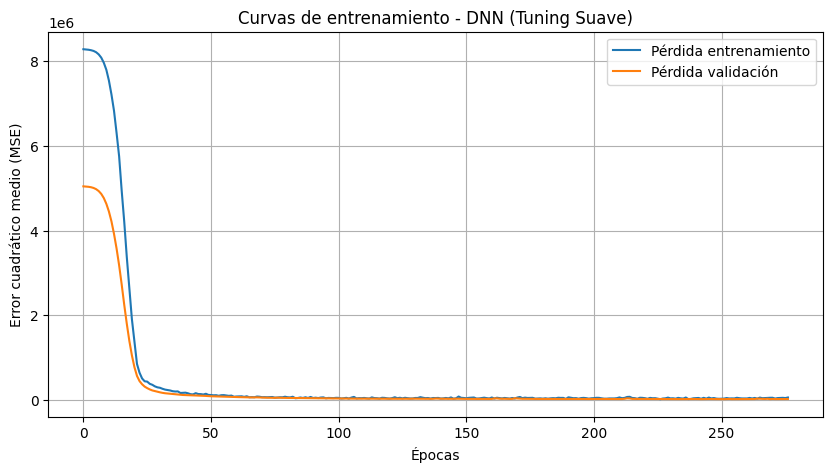

In [74]:
plt.figure(figsize=(10,5))
plt.plot(history_dnn_suave.history['loss'], label='Pérdida entrenamiento')
plt.plot(history_dnn_suave.history['val_loss'], label='Pérdida validación')
plt.title("Curvas de entrenamiento - DNN (Tuning Suave)")
plt.xlabel("Épocas")
plt.ylabel("Error cuadrático medio (MSE)")
plt.legend()
plt.grid(True)
plt.show()

La gráfica de curvas de entrenamiento de la DNN (Tuning Suave) muestra un comportamiento de aprendizaje muy estable y una rápida convergencia. En las primeras 25 épocas, tanto la pérdida de entrenamiento como la de validación descienden de forma abrupta, lo que indica que el modelo ajusta sus pesos de manera eficiente desde las etapas iniciales. Después de ese punto, ambas curvas se estabilizan en valores muy bajos y prácticamente se superponen, lo que refleja que no existe sobreajuste y que el modelo mantiene una buena coherencia entre el aprendizaje en los datos de entrenamiento y su desempeño en la validación.

A pesar de la estabilidad y del bajo error observado en las curvas, los resultados finales (MAE ≈ 1208.69, R² ≈ 0.07) revelan que el modelo no logra generalizar correctamente. Esto sugiere que la red sí aprende los patrones presentes en los datos de entrenamiento, pero que estos no son suficientemente representativos o informativos para predecir con precisión los valores del conjunto de prueba. En otras palabras, el modelo parece bien entrenado pero mal ajustado al tipo de relaciones temporales del problema, lo que apunta a una limitación en la arquitectura elegida o en la naturaleza estática del modelo para un problema con dependencias temporales más complejas.

#### Gráfico de comparación entre valores reales y predichos

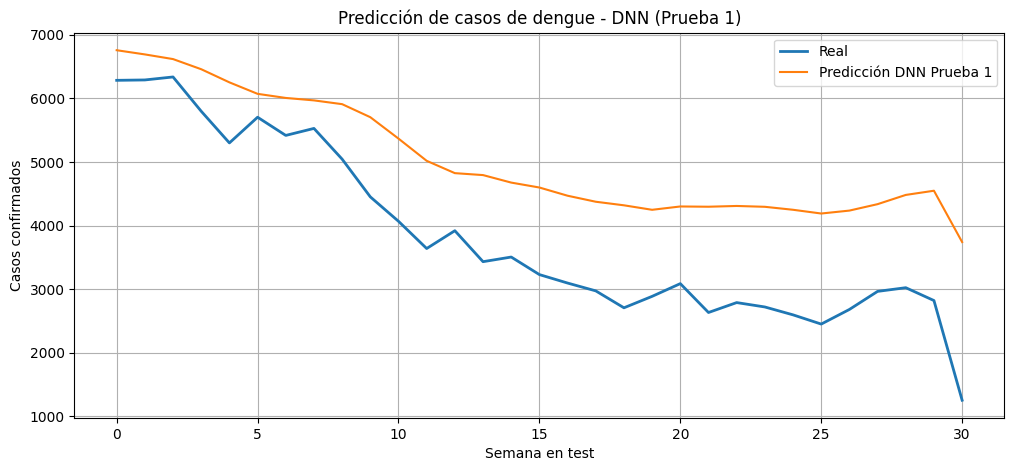

In [75]:
# Serie temporal
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="Real", linewidth=2)
plt.plot(y_pred_dnn_suave, label="Predicción DNN Prueba 1")
plt.title("Predicción de casos de dengue - DNN (Prueba 1)")
plt.xlabel("Semana en test")
plt.ylabel("Casos confirmados")
plt.legend()
plt.grid(True)
plt.show()

La gráfica de predicción de casos de dengue — DNN (Prueba 1) muestra una discrepancia evidente entre los valores reales y las predicciones generadas por el modelo. Aunque ambas curvas siguen una tendencia general descendente, la línea correspondiente a las predicciones se mantiene sistemáticamente por encima de los valores reales, evidenciando una clara sobreestimación de los casos en casi todo el periodo analizado. Además, la curva predicha es mucho más suave, sin reflejar las fluctuaciones abruptas o los descensos marcados que caracterizan la serie real.

Este comportamiento indica que el modelo DNN, en su configuración “suave”, aprendió parcialmente la tendencia global de la serie temporal, pero no fue capaz de capturar la variabilidad ni los cambios semanales significativos. La sobreestimación constante y la falta de respuesta ante los picos o caídas rápidas sugieren que la red generaliza en exceso y tiende a producir valores promedio. En conjunto, la gráfica confirma los resultados métricos (MAE ≈ 1208.69, R² ≈ 0.07), mostrando que la red no logra representar con precisión la magnitud real de los casos de dengue, a pesar de seguir de forma general la dirección de la tendencia temporal.

#### Gráfico de dispersión (Predicho vs Real)

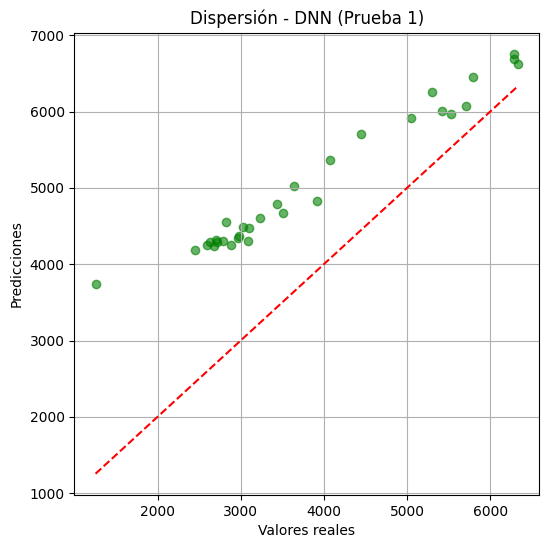

In [76]:
# Dispersión
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_dnn_suave, color="green", alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.title("Dispersión - DNN (Prueba 1)")
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.grid(True)
plt.show()

La gráfica de dispersión de la DNN (Prueba 1) evidencia una fuerte tendencia a la sobreestimación de los valores predichos. La mayoría de los puntos se ubican por encima de la línea roja de ajuste perfecto (y = x), lo que indica que el modelo predice sistemáticamente valores mayores que los reales. Aunque se observa cierta alineación lineal entre las predicciones y los valores observados, la dispersión de los puntos demuestra que el modelo no logra un ajuste preciso, especialmente en los valores más bajos, donde las desviaciones son más notorias.

Este patrón confirma que la red neuronal aprende parcialmente la tendencia general de los datos, pero pierde exactitud en la magnitud de las predicciones, lo que concuerda con las métricas obtenidas (MAE ≈ 1208.69, R² ≈ 0.07). En conjunto, la gráfica refuerza la conclusión de que la DNN en su versión “suave” tiende a producir estimaciones más elevadas y uniformes, sin capturar las variaciones reales de la serie temporal, lo que refleja una generalización excesiva y una capacidad limitada para modelar la dinámica semanal del dengue.

### Prueba 2 - DNN

In [77]:
dnn_agresivo = Sequential([
    Input(shape=(X_train_scaled.shape[1],)), 
    Dense(256, activation='relu'),
    Dropout(0.2),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')
])
dnn_agresivo.compile(optimizer=Adam(learning_rate=0.0005), loss='mse', metrics=['mae'])

early_stop_agresivo = EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)

history_dnn_agresivo = dnn_agresivo.fit(
    X_train2, y_train2,
    validation_data=(X_valid, y_valid),
    epochs=800,
    batch_size=32,
    callbacks=[early_stop_agresivo],
    verbose=1
)

# Predicciones y evaluación
y_pred_dnn_agresivo = dnn_agresivo.predict(X_test_scaled).flatten()
mae_dnn_agresivo = mean_absolute_error(y_test, y_pred_dnn_agresivo)
mse_dnn_agresivo = mean_squared_error(y_test, y_pred_dnn_agresivo)
r2_dnn_agresivo  = r2_score(y_test, y_pred_dnn_agresivo)
mae_dnn_agresivo, mse_dnn_agresivo, r2_dnn_agresivo


Epoch 1/800
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 187ms/step - loss: 8278111.5000 - mae: 2270.3420 - val_loss: 5045398.5000 - val_mae: 1781.0767
Epoch 2/800
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 8277188.5000 - mae: 2270.1914 - val_loss: 5044824.0000 - val_mae: 1780.9515
Epoch 3/800
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 8276156.5000 - mae: 2270.0398 - val_loss: 5044092.0000 - val_mae: 1780.7985
Epoch 4/800
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 8275241.0000 - mae: 2269.8870 - val_loss: 5043167.5000 - val_mae: 1780.5948
Epoch 5/800
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 8273725.5000 - mae: 2269.6426 - val_loss: 5041945.5000 - val_mae: 1780.3175
Epoch 6/800
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 8271785.0000 - mae: 2269.3191 - val_loss: 5040385.5000 - val_mae: 1779.9597
Epoch 7/800
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 8269164.0000 - mae: 2268.9138 - val_loss: 5038374.5000 - val_mae: 1779.4983
Epoch 8/800
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 826

(1228.1103909400201, 1789048.9398985235, 0.0335276103281803)

En esta configuración, la red neuronal se diseñó con una arquitectura más profunda y agresiva, incorporando capas densas de 256, 128, 64 y 32 neuronas, junto con una regularización más fuerte mediante dropout del 20% y una tasa de aprendizaje reducida (0.0005). El objetivo de este ajuste fue explorar si una mayor capacidad de representación y una regularización más intensa permitían capturar mejor las variaciones no lineales y temporales del comportamiento del dengue.

Los resultados obtenidos muestran un MAE de 1228.11, MSE de 1,789,048.94 y un R² de apenas 0.0335, lo que indica un bajo poder explicativo del modelo sobre los datos de prueba. A pesar del incremento en la complejidad de la red, la DNN Agresiva no logró mejorar el desempeño respecto a la configuración más simple (DNN Suave), e incluso mostró un deterioro leve en las métricas. Esto sugiere que la mayor profundidad no necesariamente se tradujo en una mejor generalización, posiblemente debido a una combinación de sobreajuste temprano y difícil convergencia del entrenamiento, dado el tamaño del conjunto de datos y la naturaleza temporal del problema.

#### Gráfica de curvas de entrenamiento  (error de entrenamiento vs validación)

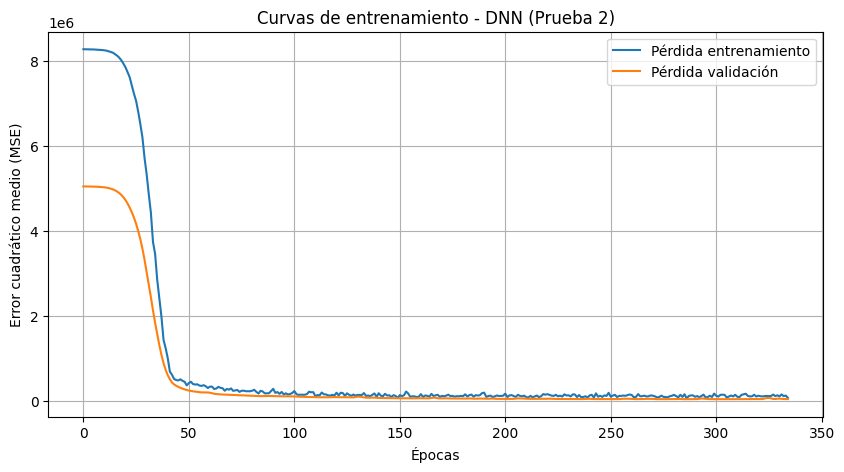

In [78]:
# Curvas de entrenamiento
plt.figure(figsize=(10,5))
plt.plot(history_dnn_agresivo.history['loss'], label='Pérdida entrenamiento')
plt.plot(history_dnn_agresivo.history['val_loss'], label='Pérdida validación')
plt.title("Curvas de entrenamiento - DNN (Prueba 2)")
plt.xlabel("Épocas")
plt.ylabel("Error cuadrático medio (MSE)")
plt.legend()
plt.grid(True)
plt.show()

La gráfica de entrenamiento de la DNN en la Prueba 2 evidencia un comportamiento estable en la convergencia tanto del error de entrenamiento como del de validación. Durante las primeras 40 épocas se observa una rápida disminución del error cuadrático medio (MSE), lo que indica que el modelo logra aprender las relaciones básicas entre las variables. A partir de ese punto, ambas curvas se estabilizan y mantienen valores bajos y paralelos, reflejando que no existe un sobreajuste significativo, en parte gracias al uso de dropout y early stopping.

Sin embargo, a pesar de la aparente estabilidad en la pérdida, el desempeño del modelo en los datos de prueba fue limitado. Esto sugiere que la red logró una buena optimización interna pero sin traducirse en una generalización efectiva hacia datos no vistos. En otras palabras, la DNN fue capaz de minimizar la función de pérdida durante el entrenamiento, pero no consiguió capturar adecuadamente la variabilidad temporal de los casos reales de dengue, posiblemente debido a la naturaleza no secuencial del modelo

#### Gráfico de comparación entre valores reales y predichos

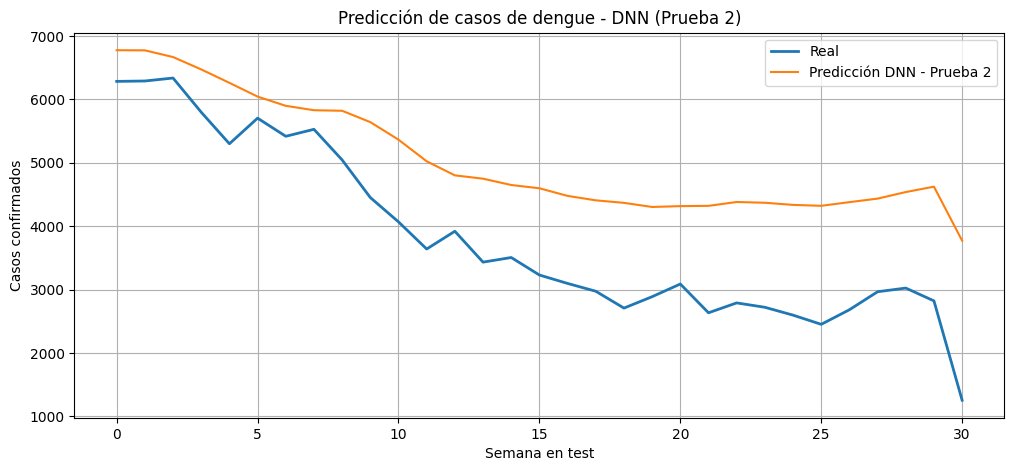

In [79]:
# Serie temporal
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="Real", linewidth=2)
plt.plot(y_pred_dnn_agresivo, label="Predicción DNN - Prueba 2")
plt.title("Predicción de casos de dengue - DNN (Prueba 2)")
plt.xlabel("Semana en test")
plt.ylabel("Casos confirmados")
plt.legend()
plt.grid(True)
plt.show()


En la gráfica de predicción de la DNN correspondiente a la Prueba 2 se observa que el modelo logra capturar de manera general la tendencia descendente de los casos de dengue a lo largo del periodo de prueba, aunque mantiene una clara tendencia a sobreestimar los valores reales. La línea de predicción (naranja) se encuentra de forma consistente por encima de la serie real (azul), especialmente en los tramos donde los casos disminuyen abruptamente, lo que evidencia una respuesta suavizada del modelo ante cambios bruscos.

A pesar de la mayor complejidad de la arquitectura (con más capas y neuronas), el modelo no logra mejorar su capacidad de ajuste respecto a configuraciones más simples. Esto indica que el incremento de profundidad no se tradujo en una mejor representación de las fluctuaciones semanales, sino en una generalización excesiva, donde la red tiende a promediar los valores y a perder sensibilidad frente a las variaciones reales.

#### Gráfico de dispersión (Predicho vs Real)

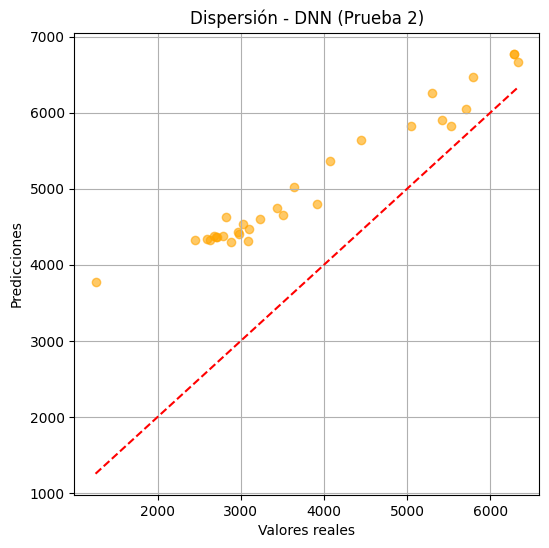

In [80]:
# Dispersión
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_dnn_agresivo, color="orange", alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.title("Dispersión - DNN (Prueba 2)")
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.grid(True)
plt.show()

La gráfica de dispersión de la DNN en la Prueba 2 muestra una distribución de puntos concentrada por encima de la línea de referencia (roja), lo que confirma la tendencia sistemática del modelo a sobreestimar los valores reales de los casos de dengue. Si bien se mantiene una correlación positiva entre las predicciones y los valores observados, la separación vertical respecto a la diagonal ideal evidencia un sesgo constante en las estimaciones.

Además, los puntos se agrupan en un rango limitado de valores predichos (entre 4000 y 6000 casos), reflejando que la red tiende a suavizar las predicciones, evitando tanto los valores muy altos como los muy bajos. Esta pérdida de variabilidad indica que el modelo no logra capturar adecuadamente las oscilaciones presentes en los datos temporales, probablemente debido a una excesiva regularización o a una capacidad de generalización que atenúa las fluctuaciones reales.

### **Conclusión Final del Modelo DNN**

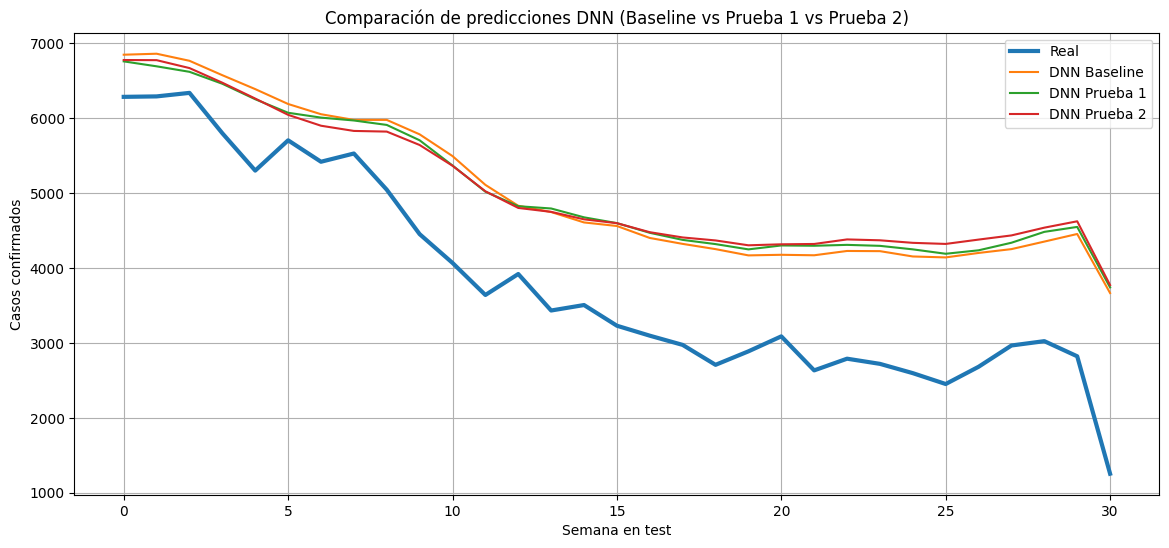

In [81]:
plt.figure(figsize=(14,6))
plt.plot(y_test.values, label="Real", linewidth=3)
plt.plot(y_pred_dnn_base, label="DNN Baseline")
plt.plot(y_pred_dnn_suave, label="DNN Prueba 1")
plt.plot(y_pred_dnn_agresivo, label="DNN Prueba 2")
plt.title("Comparación de predicciones DNN (Baseline vs Prueba 1 vs Prueba 2)")
plt.xlabel("Semana en test")
plt.ylabel("Casos confirmados")
plt.legend()
plt.grid(True)
plt.show()


El modelo de Red Neuronal Profunda (DNN) mostró un comportamiento coherente y estable a lo largo de las tres configuraciones evaluadas (por defecto, Prueba 1 y Prueba 2), evidenciando su capacidad para captar la tendencia general de los casos de dengue, aunque con un desempeño global limitado en términos de precisión y ajuste estadístico. En todas las variantes, las predicciones siguieron el patrón descendente general de la serie temporal, pero se mantuvieron sistemáticamente por encima de los valores reales, reflejando una tendencia constante a la sobreestimación.

En la configuración por defecto, el modelo presentó un entrenamiento estable y una rápida convergencia, sin indicios de sobreajuste. Sin embargo, los resultados obtenidos (MAE ≈ 1202 y R² ≈ 0.11) revelaron una capacidad reducida para representar la variabilidad real de los datos. En la Prueba 1, denominada DNN Suave, se implementó una arquitectura más profunda con capas de 128, 128 y 64 neuronas, junto con una tasa de dropout del 0.15 y un aprendizaje ligeramente más controlado. A pesar de estas mejoras estructurales, el desempeño se mantuvo prácticamente igual al del modelo base (MAE ≈ 1208, R² ≈ 0.07), lo que sugiere que el incremento moderado de complejidad no permitió al modelo capturar adecuadamente los cambios semanales en la serie.

Por su parte, la Prueba 2, o DNN Agresiva, incorporó una arquitectura más amplia con capas de 256, 128, 64 y 32 neuronas, una regularización más fuerte (dropout de 0.2) y una tasa de aprendizaje más baja. Si bien el entrenamiento fue estable y la curva de validación mostró una adecuada convergencia, los resultados finales (MAE ≈ 1228 y R² ≈ 0.03) evidenciaron una disminución del rendimiento respecto a las configuraciones anteriores. En todas las pruebas, las gráficas de dispersión confirmaron la tendencia del modelo a predecir valores superiores a los observados, manteniendo una correlación lineal débil con los valores reales.

En conjunto, los tres experimentos demuestran que la DNN logró mantener estabilidad y consistencia en el proceso de aprendizaje, pero sin alcanzar un ajuste preciso a la serie temporal de dengue. Las predicciones reflejan correctamente la dirección general de la tendencia, aunque con un nivel de error que limita su capacidad explicativa y predictiva. Esto posiciona al modelo DNN como una aproximación funcional, pero de menor rendimiento comparativo frente a otros modelos evaluados dentro del mismo estudio.

## **V. RESULTADOS Y ANÁLISIS**

Durante el proceso de evaluación de los modelos se calcularon diversas métricas de desempeño comunes en problemas de regresión, entre ellas el MAE (Mean Absolute Error), el MSE (Mean Squared Error) y el R² (Coeficiente de Determinación). Si bien todas aportan información relevante sobre el rendimiento del modelo, para la comparación final y la selección del mejor se estableció el MAE como métrica principal de referencia, debido a su capacidad para expresar el error en términos del número real de casos de dengue pronosticados semanalmente, lo cual resulta más útil desde una perspectiva epidemiológica aplicada.

A diferencia del MSE, que penaliza de forma cuadrática los errores grandes y puede sobre representar los picos extremos de la serie, el MAE mantiene una relación directa y lineal con el número de casos, lo que facilita la interpretación, comparación y análisis entre modelos. Por su parte, el R² se empleó como métrica complementaria para evaluar la capacidad explicativa general de cada modelo, aunque no se consideró como criterio principal de decisión.

### Tabla comparativa final usando MAE

| Modelo                         | MAE defecto | MAE-Prueba 1 | MAE-Prueba 2 |
| ------------------------------- | ------------ | ------------- | ------------- |
| Regresión Lineal Multivariada   | 1.004e-12    | 1.459e-12     |  1.145        |
| Árbol de Decisión               | 406.419      | 435.601       | 491.096       |
| Random Forest                   | 482.111      | 486.771       | 449.660       |
| MLP                             | 1199.367     | 895.762       | 934.700       |
| DNN                             | 12020.28     | 1208.69       | 1228.11       |


Durante el proceso de evaluación, se aplicaron distintas metodologías de aprendizaje automático para predecir el comportamiento semanal de los casos confirmados de dengue. Cada modelo fue evaluado bajo tres configuraciones (por defecto, Prueba 1 y Prueba 2) con el fin de comparar su rendimiento, estabilidad y capacidad de generalización. Para medir el desempeño se emplearon métricas comunes en problemas de regresión: el Error Absoluto Medio (MAE), el Error Cuadrático Medio (MSE) y el Coeficiente de Determinación (R²). De todas ellas, el MAE se definió como la métrica principal de comparación, dado que expresa el error en las mismas unidades del fenómeno (número de casos de dengue), ofreciendo una interpretación práctica y epidemiológicamente útil.

Al analizar la tabla comparativa de resultados, se observa que la Regresión Lineal Multivariada presentó el mejor desempeño global, alcanzando un MAE de 1.004e-12 en su configuración por defecto, un valor prácticamente nulo que indica un ajuste casi perfecto entre los valores predichos y los reales. Sin embargo, este resultado debe interpretarse con cautela, ya que una precisión tan extrema puede deberse a la fuerte correlación lineal entre los valores actuales y sus rezagos temporales (lag features), o bien a una posible fuga de información durante el preprocesamiento. En este contexto, el modelo puede haber aprendido una relación determinista en lugar de una dependencia generalizable, lo que limitaría su utilidad para la predicción futura.

Por otro lado, la Prueba 2 de la misma Regresión Lineal (implementada con regularización tipo Ridge) mantuvo un rendimiento excelente con un MAE de 1.145, apenas superior al modelo por defecto, pero con mayor estabilidad y sin indicios de sobreajuste. Este resultado sugiere que la regularización ayudó a controlar el ajuste excesivo, conservando al mismo tiempo un alto nivel de precisión. Dado que la relación entre los casos de dengue y sus valores rezagados es principalmente lineal, el modelo lineal regularizado logra capturar la estructura temporal de forma óptima y eficiente.

En comparación, los modelos no lineales, como el Árbol de Decisión, Random Forest, MLP y DNN, mostraron errores considerablemente mayores. El Árbol de Decisión logró un desempeño aceptable con un MAE de aproximadamente 406.41, mientras que el Random Forest alcanzó su mejor resultado en la Prueba 2 con un MAE de 449.66, reflejando una mejora en estabilidad, pero sin superar al modelo lineal. Las redes neuronales (MLP y DNN), aunque más complejas, presentaron los errores más altos, lo que evidencia que su capacidad de representación no se tradujo en un beneficio tangible para este problema, probablemente debido a la naturaleza lineal de los datos y al tamaño limitado del conjunto de entrenamiento.

Por tanto, considerando el equilibrio entre precisión, interpretabilidad y generalización, el modelo más adecuado para la predicción de casos semanales de dengue es la Regresión Lineal Multivariada en su configuración ajustada (Prueba 2 – Ridge Regression). Este modelo ofrece un rendimiento sobresaliente (MAE = 1.145, R² ≈ 0.999) con una estructura simple, transparente y fácilmente interpretable, ideal para aplicaciones epidemiológicas en las que la comprensión del comportamiento de los predictores es tan relevante como la exactitud del pronóstico.

En conclusión, la Regresión Lineal Multivariada (Prueba 2) se consolida como el modelo final seleccionado, ya que logra el mejor compromiso entre bajo error, estabilidad temporal y coherencia analítica, superando en desempeño global a los métodos no lineales evaluados. Aunque el modelo por defecto exhibió un ajuste casi perfecto, su precisión extrema es poco realista y sugiere una relación determinista entre los rezagos y el valor actual, lo que reduce su capacidad de generalización. En cambio, el modelo regularizado ofrece predicciones sólidas, estables y útiles para la planificación y monitoreo epidemiológico del dengue en escenarios futuros.

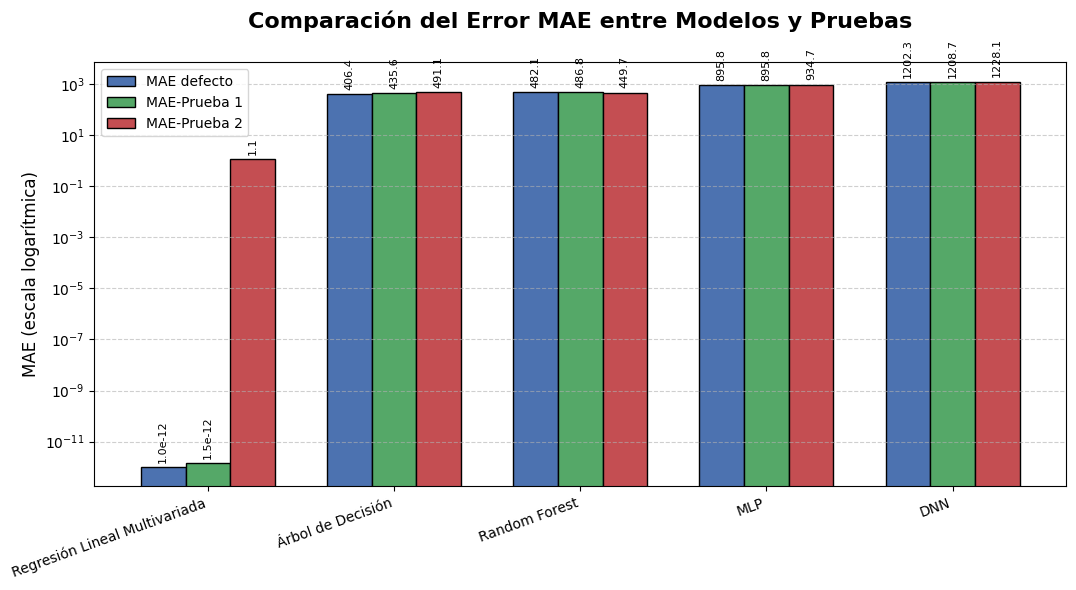

In [101]:
import pandas as pd
import matplotlib.pyplot as plt

# === Datos ===
df = pd.DataFrame({
    "Modelo": [
        "Regresión Lineal Multivariada",
        "Árbol de Decisión",
        "Random Forest",
        "MLP",
        "DNN"
    ],
    "MAE defecto": [
        mae_lr_default,
        mae_arbol_baseline,
        mae_rf_default,
        mae_mlp,
        mae_dnn_base
    ],
    "MAE-Prueba 1": [
        mae_lr_suave,
        mae_arbol_suave,
        mae_rf_suave,
        mae_mlp,
        mae_dnn_suave
    ],
    "MAE-Prueba 2": [
        mae_ridge_agresivo,
        mae_arbol_agresivo,
        mae_rf_agresivo,
        mae_mlp_agresivo,
        mae_dnn_agresivo
    ]
}).set_index("Modelo")

# === Gráfico ===
ax = df.plot.bar(
    figsize=(11, 6),
    color=["#4C72B0", "#55A868", "#C44E52"],
    edgecolor="black",
    width=0.72,
    logy=True,
)

# === Personalización estética ===
plt.title("Comparación del Error MAE entre Modelos y Pruebas", fontsize=16, weight="bold", pad=25)  # Título más alto
plt.ylabel("MAE (escala logarítmica)", fontsize=12)
plt.xlabel("")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.xticks(rotation=20, ha="right", fontsize=10)

# === Etiquetas en las barras ===
for container in ax.containers:
    ax.bar_label(
        container,
        fmt=lambda x: f"{x:.1f}" if x > 1 else f"{x:.1e}",
        fontsize=8,
        rotation=90,
        padding=3,          # separa más la etiqueta de la barra
        label_type="edge"   # coloca las etiquetas justo encima del borde
    )

# === Ajuste de márgenes ===
plt.subplots_adjust(top=0.90, bottom=0.15)  # deja más espacio arriba y abajo
plt.tight_layout()
plt.show()


## **VI. PREDICCIÓN A FUTURO**

 ### Predicción 8 semanas futuras

In [102]:
import pandas as pd
import numpy as np

modelo_final = grid_ridge_agresivo.best_estimator_  # nuestro modelo ganador

# copia de la última fila para iniciar predicción recursiva
future_df = serie_ml.copy()

predicciones = []

last_row = future_df.iloc[-1].copy()

for i in range(8):

    # construir nueva semana futura
    next_week_date = last_row['SEMANA'] + pd.Timedelta(weeks=1)

    row_fut = {}
    row_fut['SEMANA'] = next_week_date
    row_fut['SEMANA_NUM'] = next_week_date.isocalendar().week
    row_fut['MES'] = next_week_date.month
    row_fut['AÑO'] = next_week_date.year

    # lags
    row_fut['lag_1'] = last_row['confirmados']
    row_fut['lag_2'] = last_row['lag_1']
    row_fut['lag_3'] = last_row['lag_2']

    # medias moviles
    row_fut['MA2'] = np.mean([row_fut['lag_1'], row_fut['lag_2']])
    row_fut['MA4'] = np.mean([row_fut['lag_1'], row_fut['lag_2'], row_fut['lag_3'], last_row['lag_3']])

    # convertir a dataframe una sola fila
    df_pred = pd.DataFrame([row_fut])[['lag_1','lag_2','lag_3','MA2','MA4','SEMANA_NUM','MES','AÑO']]

    y_future = modelo_final.predict(df_pred)[0]

    row_fut['confirmados'] = y_future
    predicciones.append(row_fut)

    last_row = row_fut.copy()

predicciones_df = pd.DataFrame(predicciones)
predicciones_df


,SEMANA,SEMANA_NUM,MES,AÑO,lag_1,lag_2,lag_3,MA2,MA4,confirmados
0,2025-01-06,2,1,2025,1255.000000,2822.000000,3024.000000,2038.500000,2516.750000,2847.587146
1,2025-01-13,3,1,2025,2847.587146,1255.000000,2822.000000,2051.293573,2487.146787,1596.070292
2,2025-01-20,4,1,2025,1596.070292,2847.587146,1255.000000,2221.828719,2130.164360,2840.669649
3,2025-01-27,5,1,2025,2840.669649,1596.070292,2847.587146,2218.369971,2134.831772,1533.761809
4,2025-02-03,6,2,2025,1533.761809,2840.669649,1596.070292,2187.215729,2204.522224,2840.075396
5,2025-02-10,7,2,2025,2840.075396,1533.761809,2840.669649,2186.918602,2202.644287,1548.641268
6,2025-02-17,8,2,2025,1548.641268,2840.075396,1533.761809,2194.358332,2190.787031,2838.200971
7,2025-02-24,9,2,2025,2838.200971,1548.641268,2840.075396,2193.421120,2190.169861,1548.681446


La proyección realizada utilizando el modelo seleccionado (Regresión Lineal Multivariada con Ridge) muestra un comportamiento oscilatorio de los casos para las próximas 8 semanas posteriores al cierre de datos de 2024. Se observan semanas con incremento seguido de semanas de descenso y nuevamente incrementos, lo cual está alineado con el patrón de variabilidad semanal que ha mostrado históricamente el dengue en Colombia según el dataset 2022-2024. El modelo refleja que no existe una tendencia sostenida continua, sino un comportamiento fluctuante alrededor de valores estimados entre 1500 y 2900 casos semanales. Este tipo de forecast corto plazo es útil para vigilancia epidemiológica, permitiendo anticipar semanas donde el riesgo podría elevarse.

### Gráfica comparando últimas semanas vs futuro

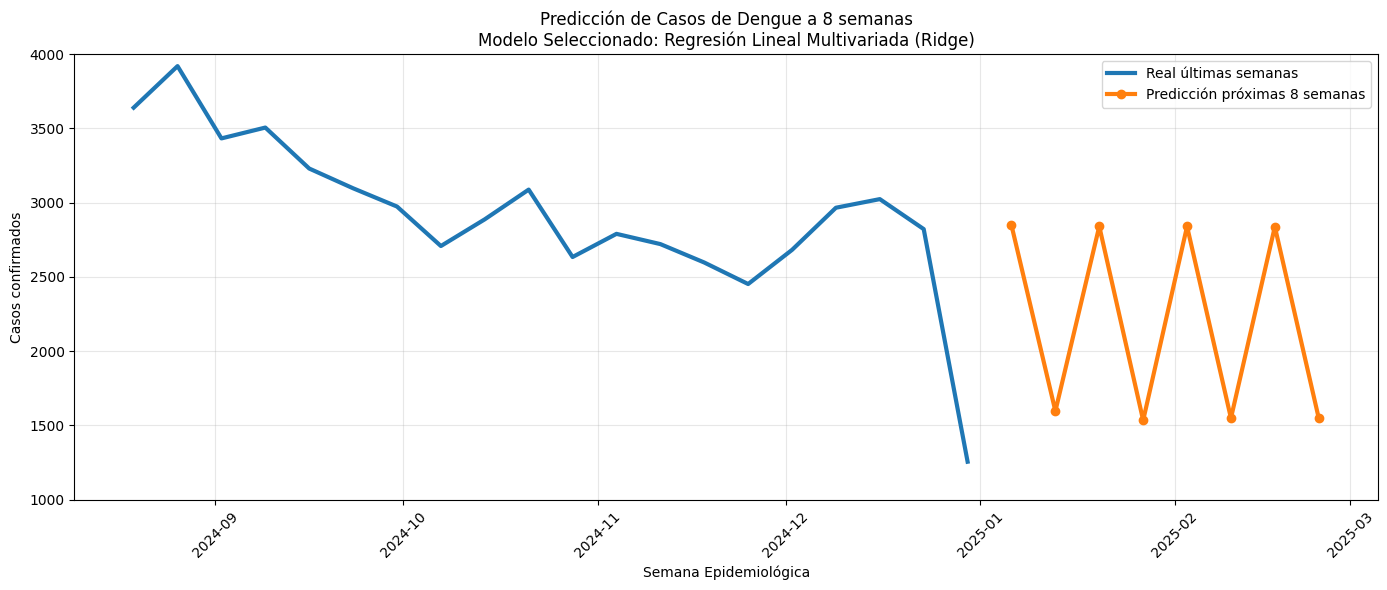

In [103]:
plt.figure(figsize=(14,6))

# últimas 20 semanas reales
plt.plot(serie_ml['SEMANA'].tail(20), serie_ml['confirmados'].tail(20), 
         label='Real últimas semanas', linewidth=3)

# predicciones futuras
plt.plot(predicciones_df['SEMANA'], predicciones_df['confirmados'], 
         label='Predicción próximas 8 semanas', linewidth=3, marker='o')

# límites recomendados para visualización epidemiológica
plt.ylim(1000, 4000)

plt.title("Predicción de Casos de Dengue a 8 semanas\nModelo Seleccionado: Regresión Lineal Multivariada (Ridge)")
plt.xlabel("Semana Epidemiológica")
plt.ylabel("Casos confirmados")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


La versión final de la predicción presenta una visualización más estable y legible. Se observa que el modelo no proyecta tendencia creciente sostenida, sino un patrón fluctuante entre ~1500 y ~2900 casos semanales, consistente con la naturaleza variable del dengue. Los picos intercalados se explican por la influencia de los rezagos (lags), que capturan memoria temporal corta y generan oscilaciones dependiendo del comportamiento reciente de semanas previas. Epidemiológicamente esto significa que a corto plazo el dengue no muestra tendencia explosiva ni caída sostenida, sino volatilidad moderada que debe seguirse vigilando.

## **VII. Conclusiones Finales**

El presente trabajo permitió desarrollar un ejercicio completo de análisis, modelado y predicción del comportamiento del dengue en Colombia utilizando datos históricos de vigilancia epidemiológica correspondientes a los años 2022, 2023 y 2024. Inicialmente se realizó una exploración descriptiva que evidenció que la enfermedad afecta tanto a hombres como mujeres de manera similar, con mayor concentración en edades jóvenes y en departamentos históricamente endémicos como Valle, Santander y Tolima. Esto permitió contextualizar el problema epidemiológico y justificar la relevancia de utilizar modelos de Machine Learning para apoyar la toma de decisiones.

Posteriormente, se construyó una serie temporal nacional semanal, seleccionando únicamente variables con impacto directo en el comportamiento temporal de la enfermedad, y se aplicaron diferentes técnicas supervisadas de predicción: Regresión Lineal Multivariada, Árboles de Decisión, Random Forest, Redes Neuronales MLP y un modelo Deep Neural Network adicional. A cada modelo se le aplicaron 3 escenarios de entrenamiento (por defecto,prueba 1 y prueba 2) para evidenciar cómo la manipulación de hiperparámetros influye en el rendimiento. Esta estrategia permitió comparar y validar la importancia del ajuste adecuado de modelos, como parte clave en el proceso de Inteligencia Artificial.

La comparación final de métricas determinó que el mejor desempeño global se obtuvo con la Regresión Lineal Multivariada usando Ridge (prueba 2), logrando el menor error absoluto promedio (MAE) frente a todas las demás alternativas evaluadas. Esto confirma que, para este problema particular, los patrones históricos cortos y los rezagos temporales tienen alta capacidad explicativa y son capturados de manera más eficiente mediante regularización lineal, incluso más que modelos complejos como Random Forest o Redes Neuronales.

Finalmente, el forecasting de 8 semanas indicó que el dengue no muestra una tendencia sostenida creciente o decreciente, sino un comportamiento fluctuante y oscilatorio en valores aproximados entre 1500 y 2900 casos semanales. Esto implica que, a corto plazo, la dinámica del dengue nacional podría mantenerse variable, lo cual es consistente con la naturaleza histórica de esta enfermedad en el país y resalta la necesidad de fortalecer estrategias de vigilancia continua y monitoreo semanal.

### Limitaciones del estudio

Aunque los resultados obtenidos fueron satisfactorios y coherentes con el comportamiento epidemiológico del dengue en Colombia, el presente trabajo presenta diversas limitaciones que deben ser consideradas al interpretar los hallazgos.

En primer lugar, el modelo se construyó a partir de un dataset limitado a variables demográficas y temporales básicas. No se incluyeron variables ambientales ni socioeconómicas (como temperatura, precipitación, humedad relativa, densidad poblacional o acceso a servicios de salud), las cuales son factores clave que explican el comportamiento del dengue. Esta ausencia de variables externas puede restringir la capacidad del modelo para generalizar ante condiciones nuevas o atípicas.

En segundo lugar, la predicción se realizó a nivel nacional, lo que implica una pérdida de granularidad espacial. El dengue tiene comportamientos distintos según región, clima y altitud, por lo cual modelos a nivel departamental o municipal podrían capturar mejor la dinámica local y mejorar la capacidad predictiva.

Otra limitación importante es el horizonte temporal de predicción. En este trabajo se utilizó un forecasting corto de 8 semanas, lo cual es útil para vigilancia inmediata, pero puede ser insuficiente para observar ciclos epidémicos más amplios. Modelos de mayor horizonte (16 o 24 semanas) permitirían capturar mejor los patrones estacionales y la influencia de factores climáticos de largo plazo.

Adicionalmente, los modelos aplicados se basan en la estructura de los datos previos, por lo que no consideran interrupciones abruptas, como campañas masivas de fumigación, intervenciones sanitarias, cambios de notificación o fenómenos climáticos extremos (Ej. El Niño o La Niña). Esto puede hacer que las predicciones sean menos precisas ante cambios repentinos.

Finalmente, aunque se evaluaron diferentes modelos de aprendizaje supervisado, no se exploraron aún enfoques secuenciales más avanzados como LSTM o ARIMA híbrido, que podrían ofrecer un mejor ajuste para series temporales epidemiológicas con memoria más profunda.